In [1]:
from analytical import *
from electronic import *
from engine import *
from integrator import *
from selector import *
from trajectory import *
from path_sampling import *
import numpy as np
from matplotlib import pyplot as plt
import pickle

In [6]:
winter_pine = "#22403D"
cranberry   = "#C93B44"
golden      = "#BEA07B"
oxford_blue  = "#1B3F6B"

palette = [winter_pine, cranberry, golden, oxford_blue]

In [7]:
# Analytical model and seed trajectory

def get_energies(x):
    H_dia = np.zeros((2,2))
    H_dia[0,0] = 0.5*0.1*np.power(x-1, 2)
    H_dia[1,1] = 0.5*0.1*np.power(x+1, 2)
    H_dia[1,0] = 0.2*0.05
    H_dia[0,1] = H_dia[1,0]

    eval, evec = np.linalg.eigh(H_dia)
    return H_dia[0,0], H_dia[1,1], eval.min(), eval.max()

x = np.linspace(-3, +3, 300)
energies = np.array([get_energies(xi) for xi in x])
# --- Seed trajectory ---

bound_A = -0.8
bound_B = 0.8

def in_stateA(q, s):
    return q<bound_A and s == 0

def in_stateB(q, s):
    return q>bound_B and s == 0

v_init = -0.0087
q_init = 1.0
coeff_init = np.array([1.0, 0.0], dtype=complex)
mass = 1836.15
act_state_init = 0
dt = 5
max_steps = 10000000

x0 = 1.0
k = 0.1
Vc = 0.2
eps = 0.05

SHO_H = DoubleHarmonic(k=2 * eps, x0=1.0, vc=Vc * eps)
C_init = SHO_H.eigvecs(q_init)

initial_snapshot = Snapshot(positions=q_init,
                            velocities=v_init,
                            coefficients=coeff_init,
                            active_state=act_state_init,
                            gauge=C_init,
                            mass=mass,
                            is_grid=True)

seedMASH = MASHEngine(model=SHO_H, dt=dt, initial_snapshot=initial_snapshot)

seed_traj = seedMASH.propagate_until_X(max_steps=max_steps, stateA=in_stateA, stateB=in_stateB)

# --- Positions ---
oscillator_positions = np.array([seed_traj[i].positions for i in range(len(seed_traj))])
active_states = np.array([seed_traj[i].active_state for i in range(len(seed_traj))])
ground_state_positions = np.copy(oscillator_positions)
ground_state_positions[active_states > 0] = np.nan
excited_state_positions = np.copy(oscillator_positions)
excited_state_positions[active_states != 1] = np.nan

# --- Coefficients ---
oscillator_coeffs = np.array([sz_from_coeff(seed_traj[i].coefficients) for i in range(len(seed_traj))])
ground_state_coeffs = np.copy(oscillator_coeffs)
ground_state_coeffs[active_states > 0] = np.nan
excited_state_coeffs = np.copy(oscillator_coeffs)
excited_state_coeffs[active_states != 1] = np.nan

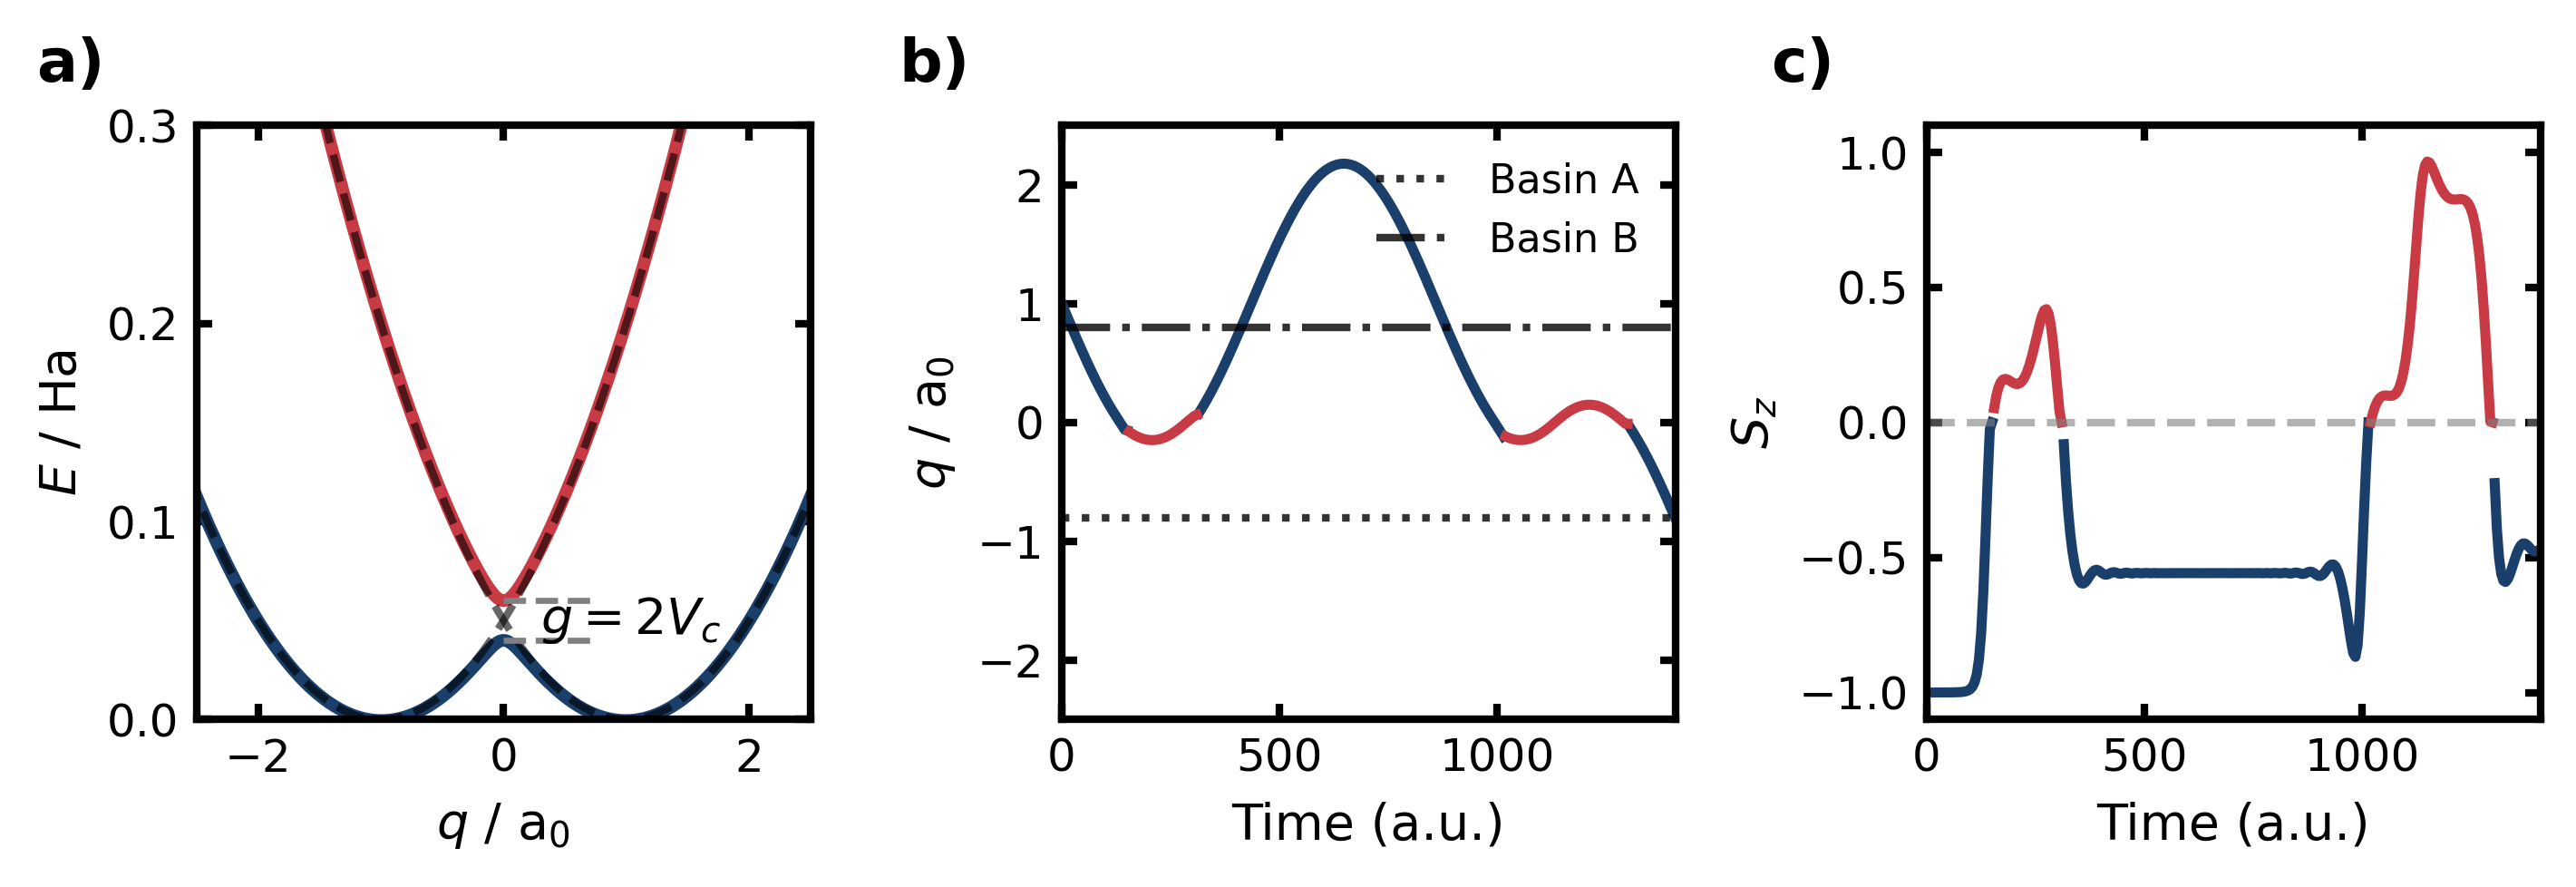

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Aesthetic Setup ---
plt.rcParams.update({
    "font.size": 10,                   
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.5,            
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
})

# Unified Color Palette
color_ground = oxford_blue   # Oxford blue
color_excited = cranberry  # Dark red
color_diabatic = 'black'

# --- 2. Create the 1x3 Double-Column Figure ---
# 7.2 inches is the standard double-column width for journals
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.6), dpi=400)

# ==========================================
# PANEL (a): Analytical Potential
# ==========================================
ax = axes[0]
x_pot = np.linspace(-3, +3, 300)
energies = np.array([get_energies(xi) for xi in x_pot])

# Plot adiabatic and diabatic lines
ax.plot(x_pot, energies[:,2], linewidth=2.5, color=color_ground, label="Ground")
ax.plot(x_pot, energies[:,3], linewidth=2.5, color=color_excited, label="Excited")
ax.plot(x_pot, energies[:,0], linestyle='--', color=color_diabatic, alpha=0.6)
ax.plot(x_pot, energies[:,1], linestyle='--', color=color_diabatic, alpha=0.6)

# Formatting
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(0.00, 0.3)
ax.set_yticks([0, 0.1, 0.2, 0.3])
ax.set_xlabel("$q$ / a$_0$")
ax.set_ylabel("$E$ / Ha")
ax.hlines([0.04, 0.06], xmin=0, xmax=0.75, colors='gray', linestyles='--', linewidth=1.2)
ax.text(0.3, 0.05, r"$g = 2V_c$", va='center')
# ax.annotate(r"$g = 2V_c$", 
#             xy=(0.75, 0.05),         # The point the arrow points to (end of the hlines)
#             xytext=(1.2, 0.12),      # The new, safe position of the text
#             va='center', ha='left',
#             fontsize=10,
#             arrowprops=dict(arrowstyle="->", color='gray', linewidth=1.2, shrinkA=0, shrinkB=3))

# ==========================================
# PANEL (b): Seed Trajectory Positions
# ==========================================
ax = axes[1]
time_array = np.arange(len(seed_traj)) * dt

ax.plot(time_array, ground_state_positions, color=color_ground, linewidth=2)
ax.plot(time_array, excited_state_positions, color=color_excited, linewidth=2)

ax.axhline(y=bound_A, linestyle=":", color='black', alpha=0.8, label="Basin A")
ax.axhline(y=bound_B, linestyle="-.", color='black', alpha=0.8, label="Basin B")

# Formatting
ax.set_xlabel("Time (a.u.)")
ax.set_ylabel("$q$ / a$_0$")
ax.set_xlim(0, time_array[-1])
ax.set_ylim(-2.5, 2.5)
ax.legend(loc='upper right', frameon=False, fontsize=8)

# ==========================================
# PANEL (c): Seed Trajectory Sz
# ==========================================
ax = axes[2]

ax.plot(time_array, ground_state_coeffs, color=color_ground, linewidth=2)
ax.plot(time_array, excited_state_coeffs, color=color_excited, linewidth=2)
ax.axhline(y=0, linestyle="--", color='gray', alpha=0.6)

# Formatting
ax.set_xlabel("Time (a.u.)")
ax.set_ylabel(r"$S_z$")
ax.set_xlim(0, time_array[-1])
ax.set_ylim(-1.1, 1.1)

# ==========================================
# Universal Aesthetics & Export
# ==========================================
# Apply tick directions and panel labels
panel_labels = ['a)', 'b)', 'c)']
for i, ax in enumerate(axes):
    ax.tick_params(direction='in', top=True, right=True)
    # Add publication-style panel letters
    ax.text(-0.15, 1.15, panel_labels[i], transform=ax.transAxes, 
            fontsize=12, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.savefig("Figure1_Model_and_Seed.png", dpi=400, bbox_inches='tight')
plt.show()

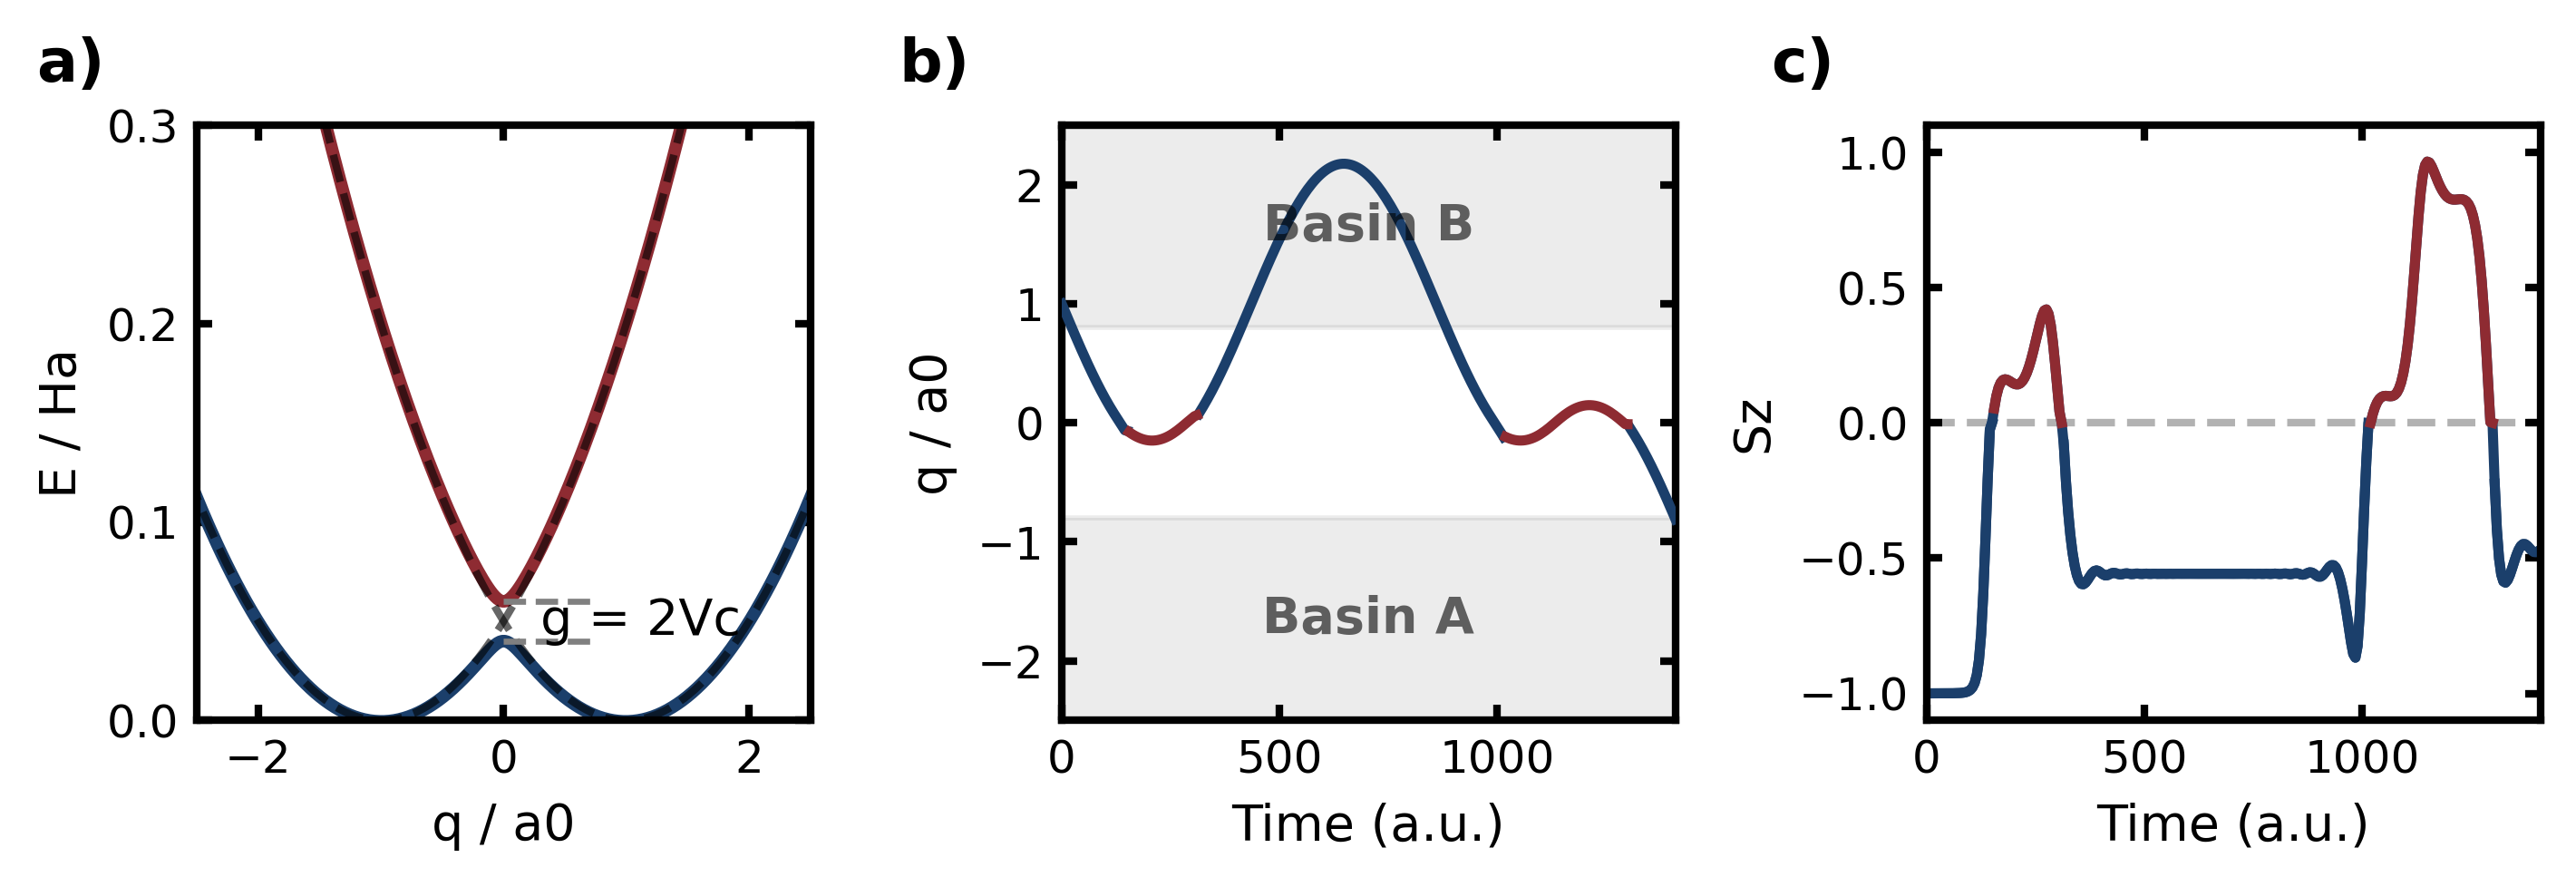

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Aesthetic Setup ---
plt.rcParams.update({
    "font.size": 10,                   
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.5,            
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
})

# Unified Color Palette
oxford_blue = "#1B3F6B"
color_ground = oxford_blue   
color_excited = cranberry  
color_diabatic = 'black'

# Basin boundaries (assuming these are defined in your workspace)
bound_A = -0.8
bound_B = 0.8

# --- 2. Create the 1x3 Double-Column Figure ---
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.6), dpi=400)

# ==========================================
# PANEL (a): Analytical Potential
# ==========================================
ax = axes[0]
x_pot = np.linspace(-3, +3, 300)
# Assuming get_energies is defined in your workspace
energies = np.array([get_energies(xi) for xi in x_pot])

ax.plot(x_pot, energies[:,2], linewidth=2.5, color=color_ground, label="Ground")
ax.plot(x_pot, energies[:,3], linewidth=2.5, color=color_excited, label="Excited")
ax.plot(x_pot, energies[:,0], linestyle='--', color=color_diabatic, alpha=0.6)
ax.plot(x_pot, energies[:,1], linestyle='--', color=color_diabatic, alpha=0.6)

ax.set_xlim(-2.5, 2.5)
ax.set_ylim(0.00, 0.3)
ax.set_yticks([0, 0.1, 0.2, 0.3])
ax.set_xlabel("q / a0")
ax.set_ylabel("E / Ha")
ax.hlines([0.04, 0.06], xmin=0, xmax=0.75, colors='gray', linestyles='--', linewidth=1.2)
ax.text(0.3, 0.05, "g = 2Vc", va='center')

# ==========================================
# PANEL (b): Seed Trajectory Positions
# ==========================================
ax = axes[1]
# Assuming seed_traj and dt are defined in your workspace
time_array = np.arange(len(seed_traj)) * dt

# Plot the trajectory
ax.plot(time_array, ground_state_positions, color=color_ground, linewidth=2, zorder=3)
ax.plot(time_array, excited_state_positions, color=color_excited, linewidth=2, zorder=3)

# Add shaded regions for Basin A and Basin B
ax.axhspan(-2.5, bound_A, color='gray', alpha=0.15, zorder=1)
ax.axhspan(bound_B, 2.5, color='gray', alpha=0.15, zorder=1)

# Direct text annotations instead of a legend
# Placed centrally in the x-axis, and vertically in the middle of the shaded regions
ax.text(time_array[-1] / 2, (bound_A - 2.5) / 2, 'Basin A', 
        ha='center', va='center', fontsize=10, fontweight='bold', alpha=0.6)
ax.text(time_array[-1] / 2, (bound_B + 2.5) / 2, 'Basin B', 
        ha='center', va='center', fontsize=10, fontweight='bold', alpha=0.6)

ax.set_xlabel("Time (a.u.)")
ax.set_ylabel("q / a0")
ax.set_xlim(0, time_array[-1])
ax.set_ylim(-2.5, 2.5)

# ==========================================
# PANEL (c): Seed Trajectory Sz
# ==========================================
ax = axes[2]

# Create a continuous Sz array to bridge the visual gaps
# This replaces NaN values in the ground array with the excited array values
continuous_Sz = np.copy(ground_state_coeffs)
mask = np.isnan(continuous_Sz)
if np.any(mask):
    continuous_Sz[mask] = excited_state_coeffs[mask]

# Plot the continuous line underneath to connect the hops
ax.plot(time_array, continuous_Sz, color=oxford_blue, linewidth=2, alpha=1.0, zorder=1)

# Plot the colored state-dependent segments on top
ax.plot(time_array, ground_state_coeffs, color=color_ground, linewidth=2, zorder=2)
ax.plot(time_array, excited_state_coeffs, color=color_excited, linewidth=2, zorder=2)

ax.axhline(y=0, linestyle="--", color='gray', alpha=0.6, zorder=0)

ax.set_xlabel("Time (a.u.)")
ax.set_ylabel("Sz")
ax.set_xlim(0, time_array[-1])
ax.set_ylim(-1.1, 1.1)

# ==========================================
# Universal Aesthetics & Export
# ==========================================
panel_labels = ['a)', 'b)', 'c)']
for i, ax in enumerate(axes):
    ax.tick_params(direction='in', top=True, right=True)
    ax.text(-0.15, 1.15, panel_labels[i], transform=ax.transAxes, 
            fontsize=12, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.savefig("Figure1_Model_and_Seed.png", dpi=400, bbox_inches='tight')
plt.show()

In [8]:
# Load data for temperature
# Unless you have a computer that is as cool as mine, loading everything here will blow up your memory.


temperatures = [300, 400, 500, 600, 700, 800, 900, 1000, 2526, 4052, 5578, 7105, 8631, 10157, 11684,
                13210, 14736, 16263, 17789, 19315, 20842, 22368, 23894, 25421, 26947, 28473, 30000]

grand_list_T = []
for temps in temperatures:
    with open(f'data/TPS_data_T{temps}K.pkl', 'rb') as f:
        obj = pickle.load(f)
        grand_list_T.append(obj)

tps_ensemble_list = [grand_list_T[i]['tps_ensemble'] for i in range(len(grand_list_T))]
naive_tps_ensemble_list = [grand_list_T[i]['naive_ensemble'] for i in range(len(grand_list_T))]
MC_rate_list = [grand_list_T[i]['MC rate'] for i in range(len(grand_list_T))]
TT_dist_list = [grand_list_T[i]['Transition time'] for i in range(len(grand_list_T))]
q_hop_dist_list = [grand_list_T[i]['hopping geometries'] for i in range(len(grand_list_T))]
autocorr_list = [grand_list_T[i]['Autocorrelation'] for i in range(len(grand_list_T))]

In [9]:
# load further
processor = PathSampling(selector=None, seed_traj=None, max_iter=None, max_length=None, in_stateA=None, in_stateB=None)
TTS = [processor.hop_statistics(ensemble) for ensemble in tps_ensemble_list]
print(TTS[0][0])
mean_hop_list = [TTS[i][0] for i in range(len(TTS))]
mean_hop_std = [TTS[i][1] for i in range(len(TTS))]
mtt_list = [np.mean(TT_dist_list[i]) for i in range(len(TT_dist_list))]
mtt_std_list = [np.std(TT_dist_list[i]) for i in range(len(TT_dist_list))]

total number of hops: 0
Mean Number of Hops: 0.000
Standard Deviation of Hops: 0.000
total number of hops: 0
Mean Number of Hops: 0.000
Standard Deviation of Hops: 0.000
total number of hops: 0
Mean Number of Hops: 0.000
Standard Deviation of Hops: 0.000
total number of hops: 0
Mean Number of Hops: 0.000
Standard Deviation of Hops: 0.000
total number of hops: 0
Mean Number of Hops: 0.000
Standard Deviation of Hops: 0.000
total number of hops: 0
Mean Number of Hops: 0.000
Standard Deviation of Hops: 0.000
total number of hops: 0
Mean Number of Hops: 0.000
Standard Deviation of Hops: 0.000
total number of hops: 0
Mean Number of Hops: 0.000
Standard Deviation of Hops: 0.000
total number of hops: 900
Mean Number of Hops: 0.106
Standard Deviation of Hops: 0.513
total number of hops: 2300
Mean Number of Hops: 0.271
Standard Deviation of Hops: 0.863
total number of hops: 2896
Mean Number of Hops: 0.341
Standard Deviation of Hops: 0.863
total number of hops: 3970
Mean Number of Hops: 0.467
Sta

In [11]:
# Load data for coupling
# Unless you have a computer that is as cool as mine, loading everything here will blow up your memory.

Vcx10 = [1,2,3,4,5,6,7,8]

grand_list_V = []
for coupling in Vcx10:
    with open(f'data/TPS_data_Vc{coupling}.pkl', 'rb') as f:
        obj = pickle.load(f)
        grand_list_V.append(obj)

tps_ensemble_list_V = [grand_list_V[i]['tps_ensemble'] for i in range(len(grand_list_V))]
naive_tps_ensemble_list_V = [grand_list_V[i]['naive_ensemble'] for i in range(len(grand_list_V))]
MC_rate_list_V = [grand_list_V[i]['MC rate'] for i in range(len(grand_list_V))]
TT_dist_list_V = [grand_list_V[i]['Transition time'] for i in range(len(grand_list_V))]
q_hop_dist_list_V = [grand_list_V[i]['hopping geometries'] for i in range(len(grand_list_V))]
autocorr_list_V = [grand_list_V[i]['Autocorrelation'] for i in range(len(grand_list_V))]

In [12]:
processor = PathSampling(selector=None, seed_traj=None, max_iter=None, max_length=None, in_stateA=None, in_stateB=None)
TTS_V = [processor.hop_statistics(ensemble) for ensemble in tps_ensemble_list_V]
mean_hop_list_V = [TTS_V[i][0] for i in range(len(TTS_V))]
mean_hop_std_V = [TTS_V[i][1] for i in range(len(TTS_V))]
mtt_list_V = [np.mean(TT_dist_list_V[i]) for i in range(len(TT_dist_list_V))]
mtt_std_list_V = [np.std(TT_dist_list_V[i]) for i in range(len(TT_dist_list_V))]

total number of hops: 9886
Mean Number of Hops: 1.163
Standard Deviation of Hops: 1.301
total number of hops: 5208
Mean Number of Hops: 0.613
Standard Deviation of Hops: 1.167
total number of hops: 3794
Mean Number of Hops: 0.446
Standard Deviation of Hops: 1.228
total number of hops: 1836
Mean Number of Hops: 0.216
Standard Deviation of Hops: 0.970
total number of hops: 1374
Mean Number of Hops: 0.162
Standard Deviation of Hops: 0.936
total number of hops: 1376
Mean Number of Hops: 0.162
Standard Deviation of Hops: 1.110
total number of hops: 778
Mean Number of Hops: 0.092
Standard Deviation of Hops: 0.479
total number of hops: 492
Mean Number of Hops: 0.058
Standard Deviation of Hops: 0.660


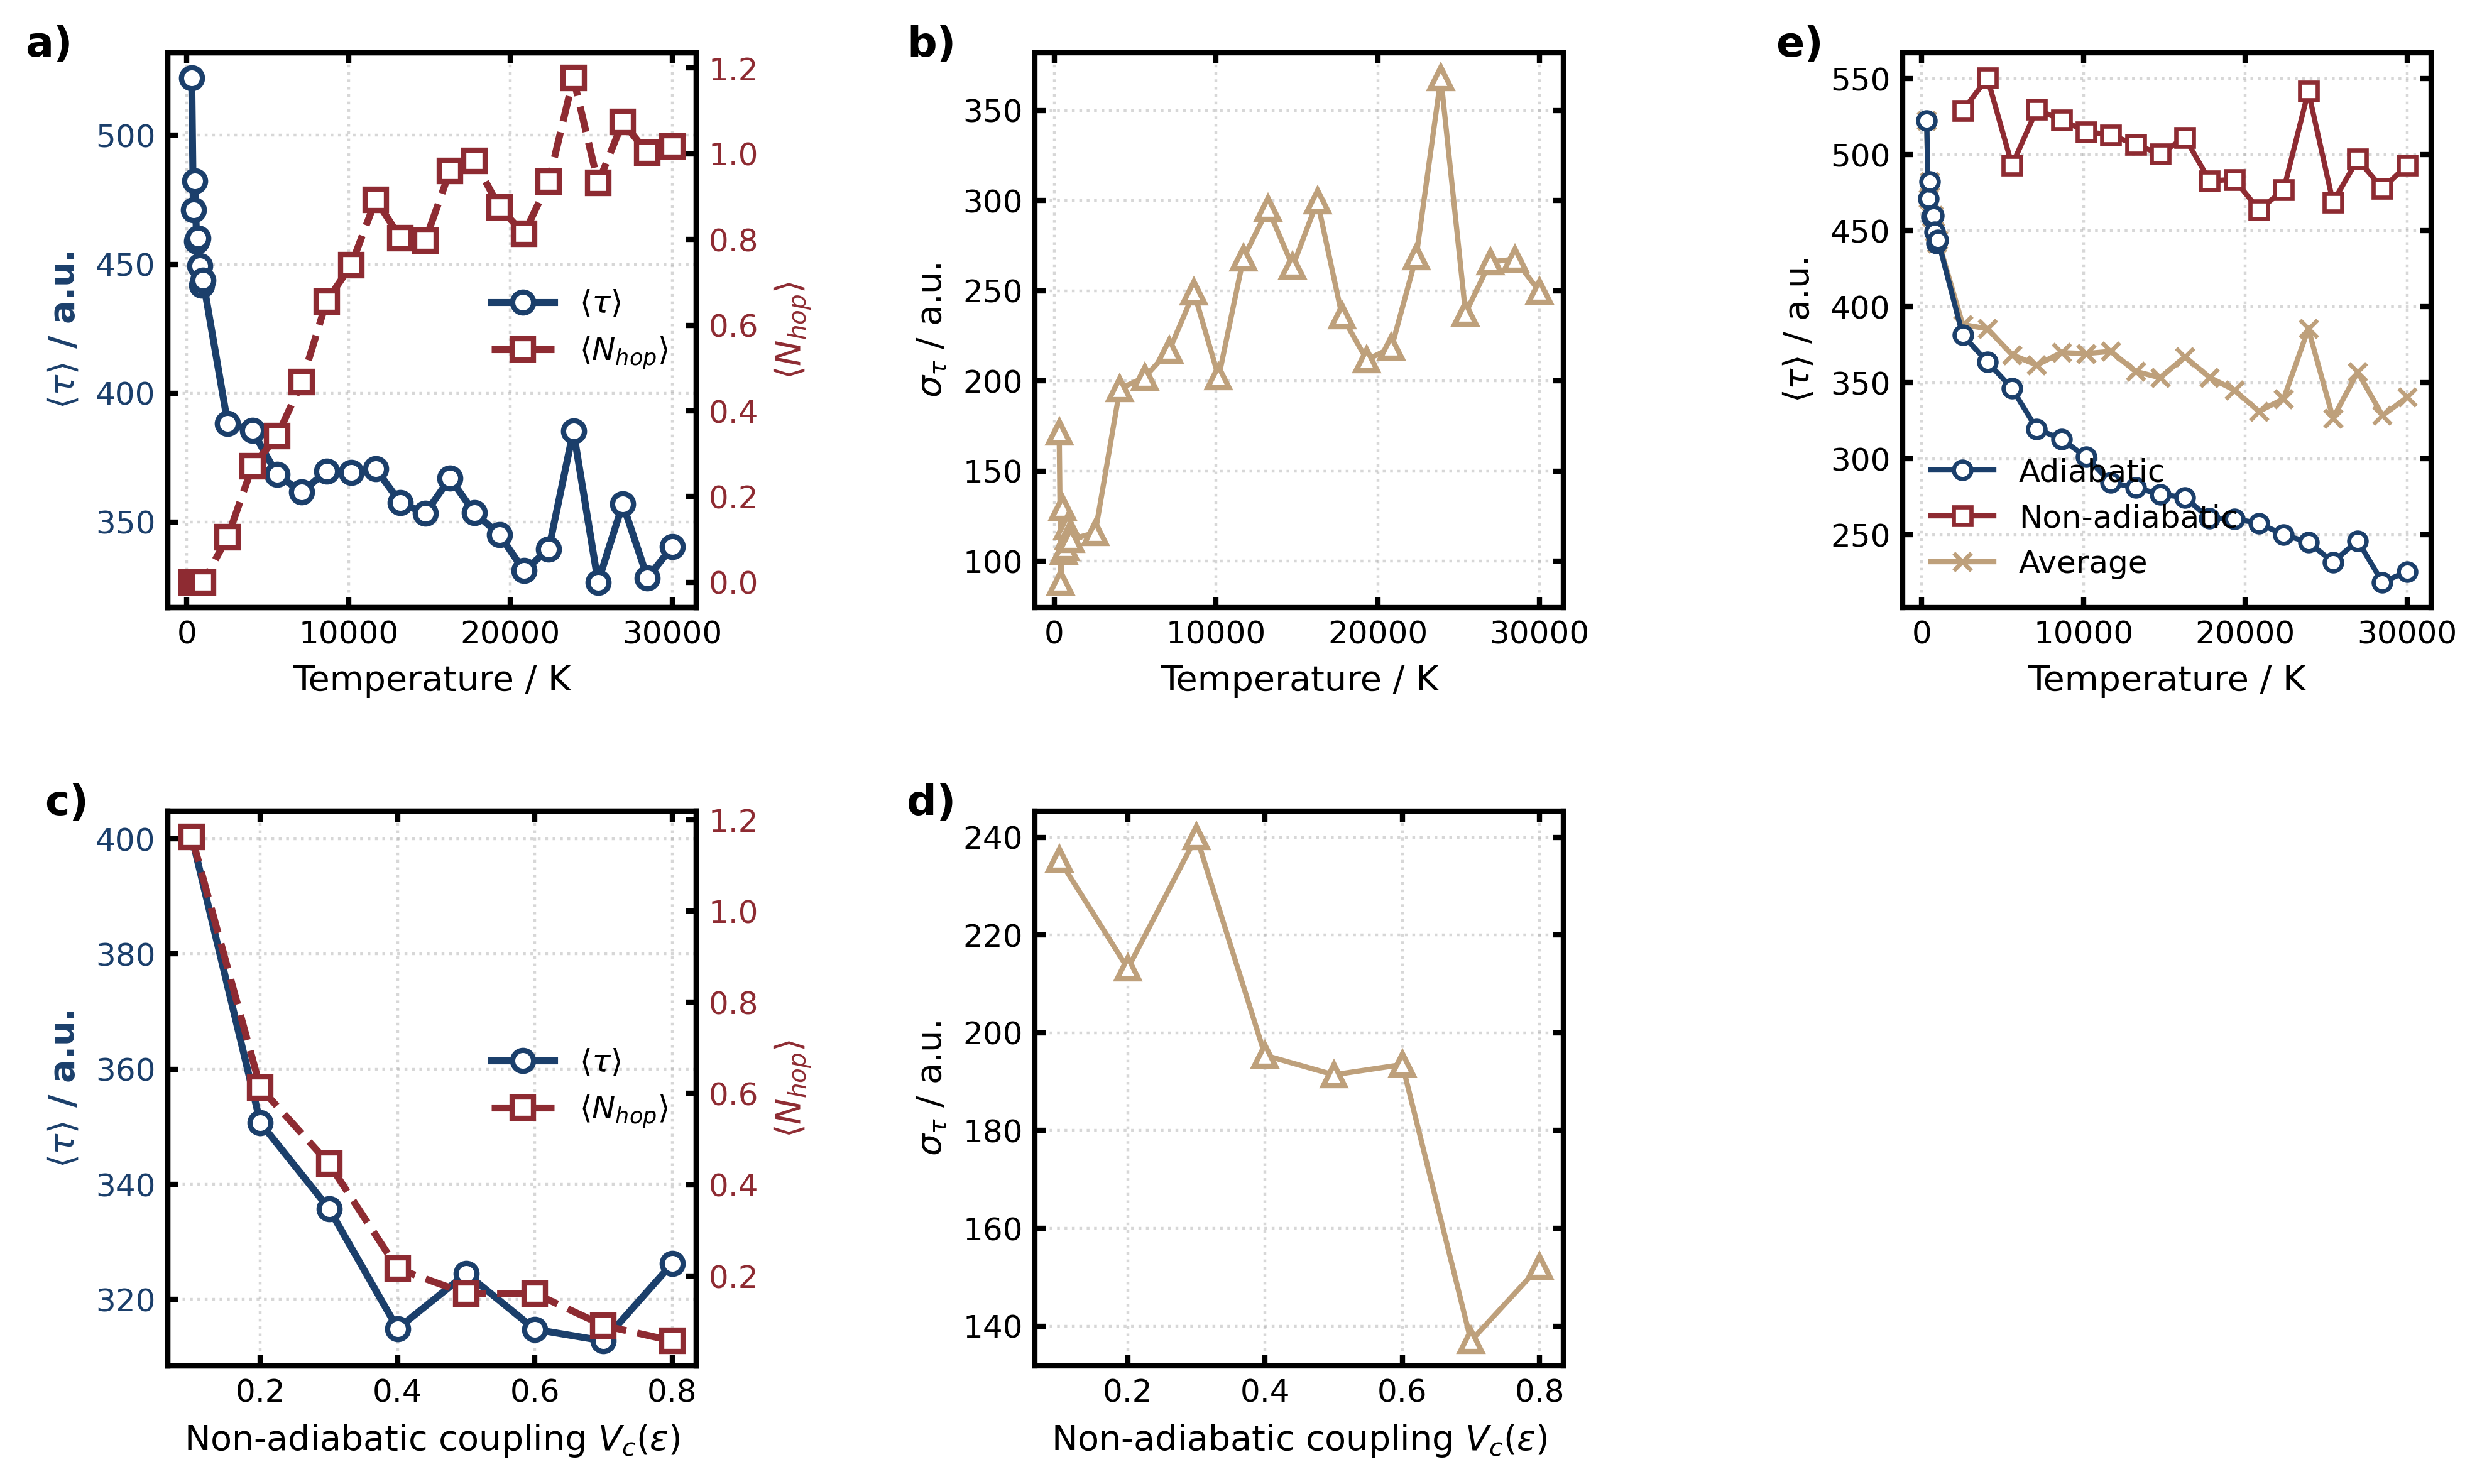

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# The pristine palette
winter_pine = "#22403D"
cranberry   = "#8E2B32"
golden      = "#BEA07B"
oxford_blue = "#1B3F6B"

def remove_off_grid(traj):
    return Trajectory([snap for snap in traj if snap.is_grid])

def plot_combined_kinetics_publish(temperature_sweep, mtt_list, mean_hop_list, mtt_std_list, Vc_v, hops_v, stds_v, mtts_v):
    # ==========================================
    # 1. Aesthetic Setup (Journal Standard)
    # ==========================================
    plt.rcParams.update({
        "font.size": 10,                   
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.5,            
        "xtick.major.width": 1.5,
        "ytick.major.width": 1.5,
        "xtick.minor.width": 1.0,
        "ytick.minor.width": 1.0,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
    })

    # Sort the arrays to guarantee strict left-to-right line drawing
    temps = np.array(temperature_sweep)
    sort_idx = np.argsort(temps)
    temps = temps[sort_idx]
    mtts = np.array(mtt_list)[sort_idx]
    hops = np.array(mean_hop_list)[sort_idx]
    stds = np.array(mtt_std_list)[sort_idx]

    # Create a 1x2 double-column figure (7.2 inches wide)
    fig, axes = plt.subplots(2, 3, figsize=(10.0, 6.0), dpi=400)

    # ==========================================
    # PANEL (a): MTT & MNT Overlay
    # ==========================================
    ax1 = axes[0][0]
    
    # Left Axis: MTT
    ax1.set_xlabel('Temperature / K', fontweight='medium')
    ax1.set_ylabel(r'$\langle \tau \rangle$ / a.u.', color=oxford_blue, fontweight='bold')
    
    line1 = ax1.plot(temps, mtts, color=oxford_blue, linewidth=2, 
                     linestyle='-', marker='o', markersize=6, markerfacecolor='white', 
                     markeredgewidth=1.5, zorder=3, label=r'$\langle \tau \rangle$')
    
    ax1.tick_params(axis='y', labelcolor=oxford_blue, direction='in')
    ax1.tick_params(axis='x', direction='in', top=True)
    ax1.grid(True, linestyle=':', alpha=0.5, zorder=0)

    # Right Axis: MNT
    ax2 = ax1.twinx()
    ax2.set_ylabel(r'$\langle N_{hop} \rangle$', color=cranberry, fontweight='bold')
    
    line2 = ax2.plot(temps, hops, color=cranberry, linewidth=2, 
                     linestyle='--', marker='s', markersize=6, markerfacecolor='white', 
                     markeredgewidth=1.5, zorder=4, label=r'$\langle N_{hop} \rangle$')
    
    ax2.tick_params(axis='y', labelcolor=cranberry, direction='in')

    # Combine legends into a minimalist box
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right', frameon=False, fontsize=9)

    # Ensure right spine is thick for ax2
    for spine in ax2.spines.values():
        spine.set_linewidth(1.5)

    # ==========================================
    # PANEL (b): Standard Deviation
    # ==========================================
    ax3 = axes[0][1]
    
    ax3.plot(temps, stds, color=golden, linewidth=1.5, linestyle='-', 
             marker='^', markersize=6, markerfacecolor='white', 
             markeredgewidth=1.5, zorder=3)

    ax3.set_xlabel("Temperature / K", fontweight='medium')
    ax3.set_ylabel(r"$\sigma_\tau$ / a.u.", fontweight='medium')
    
    ax3.tick_params(direction='in', top=True, right=True)
    ax3.grid(True, linestyle=':', alpha=0.5, zorder=0)

    # 
    # PANEL (c): MTT & MNT Overlay for V
    #

    ax4 = axes[1][0]
    
    # Left Axis: MTT
    ax4.set_xlabel(r"Non-adiabatic coupling $V_c$($\epsilon$)", fontweight='medium')
    ax4.set_ylabel(r'$\langle \tau \rangle$ / a.u.', color=oxford_blue, fontweight='bold')
    
    line1 = ax4.plot(Vc_v, mtts_v, color=oxford_blue, linewidth=2, 
                     linestyle='-', marker='o', markersize=6, markerfacecolor='white', 
                     markeredgewidth=1.5, zorder=3, label=r'$\langle \tau \rangle$')
    
    ax4.tick_params(axis='y', labelcolor=oxford_blue, direction='in')
    ax4.tick_params(axis='x', direction='in', top=True)
    ax4.grid(True, linestyle=':', alpha=0.5, zorder=0)

    # Right Axis: MNT
    ax5 = ax4.twinx()
    ax5.set_ylabel(r'$\langle N_{hop} \rangle$', color=cranberry, fontweight='bold')
    
    line2 = ax5.plot(Vc_v, hops_v, color=cranberry, linewidth=2, 
                     linestyle='--', marker='s', markersize=6, markerfacecolor='white', 
                     markeredgewidth=1.5, zorder=4, label=r'$\langle N_{hop} \rangle$')
    
    ax5.tick_params(axis='y', labelcolor=cranberry, direction='in')

    # Combine legends into a minimalist box
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax5.legend(lines, labels, loc='center right', frameon=False, fontsize=9)

    # Ensure right spine is thick for ax2
    for spine in ax5.spines.values():
        spine.set_linewidth(1.5)
    
    #
    # PANEL (d) Standard deviation
    #

    ax6 = axes[1][1]
    
    ax6.plot(Vc_v, stds_v, color=golden, linewidth=1.5, linestyle='-', 
             marker='^', markersize=6, markerfacecolor='white', 
             markeredgewidth=1.5, zorder=3)

    ax6.set_xlabel(r"Non-adiabatic coupling $V_c$($\epsilon$)", fontweight='medium')
    ax6.set_ylabel(r"$\sigma_\tau$ / a.u.", fontweight='medium')
    
    ax6.tick_params(direction='in', top=True, right=True)
    ax6.grid(True, linestyle=':', alpha=0.5, zorder=0)

    #
    # Kinetic bifurcation plot
    #

    temps = temperature_sweep
    tps_list = tps_ensemble_list
    mean_hopful = []
    mean_hopless = []
    TT_dist_list_rev = TT_dist_list
    mean_total = [np.mean(TT_dist_list_rev[i]) for i in range(len(TT_dist_list))]
    proportion_hopful = []

    for i in range(len(tps_list)):
        new_ensemble = tps_list[i][1500:]
        nohop_ensemble = [traj for traj in new_ensemble if not any(snap.hop for snap in traj)]
        nohop_ensemble_no_offgrid = [remove_off_grid(traj) for traj in nohop_ensemble]
        TT_dist_nohop = [(len(traj)-1) * dt for traj in nohop_ensemble_no_offgrid]
        
        mean_hopless.append(np.mean(TT_dist_nohop))

        hop_ensemble = [traj for traj in new_ensemble if any(snap.hop for snap in traj)]
        if len(hop_ensemble) > 50:
            hop_ensemble_no_offgrid = [remove_off_grid(traj) for traj in hop_ensemble]
            TT_dist_hop = [(len(traj)-1) * dt for traj in hop_ensemble_no_offgrid]
            mean_hopful.append(np.mean(TT_dist_hop))
            proportion_hopful.append(len(hop_ensemble_no_offgrid)/len(new_ensemble))
        else:
            mean_hopful.append(np.nan)
            proportion_hopful.append(0)
    
    #
    # Kinetic bifurcation graph
    #

    ax7 = axes[0][2]

    ax7.plot(temps, mean_hopless, color=oxford_blue, linewidth=1.5, marker='o', 
            markersize=5, markerfacecolor='white', markeredgewidth=1.2, zorder=3,
            label='Adiabatic')

    # Hop-ful line (Cranberry)
    ax7.plot(temps, np.array(mean_hopful), color=cranberry, linewidth=1.5, marker='s', 
            markersize=5, markerfacecolor='white', markeredgewidth=1.2, zorder=4,
            label='Non-adiabatic')

    # Reference total MTT (Winter Pine)
    ax7.plot(temps, np.array(mean_total), color=golden, linewidth=1.5, marker='x', 
            markersize=5, markeredgewidth=1.2, zorder=2,
            label='Average')
    
    # ==========================================
    # 3. LABELS & FORMATTING
    # ==========================================
    # Clean, journal-style axis labels
    ax7.set_xlabel("Temperature / K", fontweight='medium')
    ax7.set_ylabel(r"$\langle \tau \rangle$ / a.u.", fontweight='medium')
    
    # Grid and Ticks
    ax7.grid(True, linestyle=':', alpha=0.5, zorder=0)
    ax7.tick_params(direction='in', top=True, right=True)
    
    # Thicken axes
    for spine in ax7.spines.values():
        spine.set_linewidth(1.5)
        
    # Legend - no frame, compact
    ax7.legend(loc='best', fontsize=9, frameon=False)
    
    axes[1, 2].axis('off')

    # ==========================================
    # FINAL POLISH & EXPORT
    # ==========================================
    # Add publication-style panel letters
    ax1.text(-0.18, 1.05, 'a)', transform=ax1.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')
    ax3.text(-0.15, 1.05, 'b)', transform=ax3.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')
    ax4.text(-0.15, 1.05, 'c)', transform=ax4.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')
    ax6.text(-0.15, 1.05, 'd)', transform=ax6.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')
    ax7.text(-0.15, 1.05, 'e)', transform=ax7.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')

    plt.tight_layout(w_pad=2.5, h_pad=2.5)
    plt.savefig("Combined_Kinetic_Statistics.png", dpi=400, bbox_inches='tight')
    plt.show()

# Run the plot:
Vc_v = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]
plot_combined_kinetics_publish(temperatures, mtt_list, mean_hop_list, mtt_std_list, Vc_v, mean_hop_list_V, mtt_std_list_V, mtt_list_V)

[0, 0, 0, 0, 0, 0, 0, 0, 0.046582754970003526, 0.11704505352311492, 0.15127632043289024, 0.19997647335607577, 0.2706740383484296, 0.31808022585578166, 0.3774850017644983, 0.3384307728502529, 0.3429008351958593, 0.3903070227032114, 0.418303728973062, 0.3796023997176803, 0.3567815551111634, 0.3944241853899541, 0.47300317609692977, 0.39983531349253026, 0.44230090577579106, 0.4232443241971533, 0.42865545229972946]


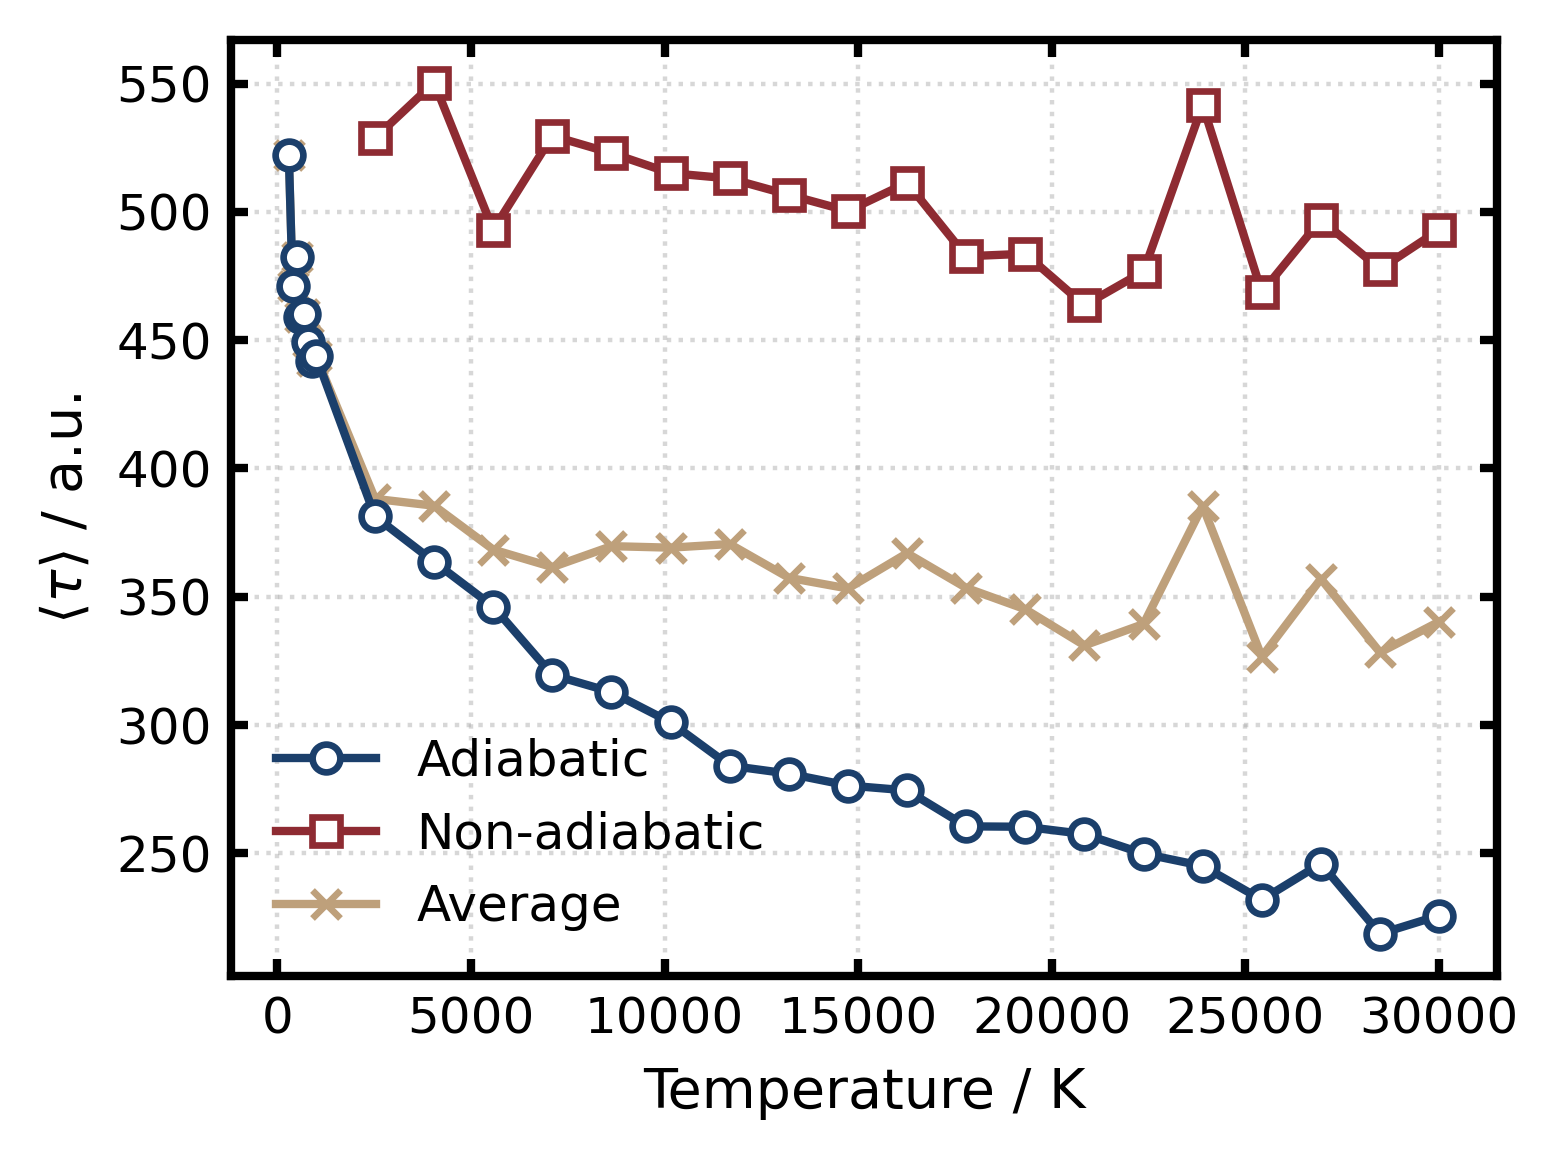

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Your pristine palette
winter_pine = "#22403D"
cranberry   = "#8E2B32"
golden      = "#BEA07B"
oxford_blue = "#1B3F6B"

def remove_off_grid(traj):
    return Trajectory([snap for snap in traj if snap.is_grid])

def plot_kinetic_bifurcation_strict_publish(temperature_sweep, tps_ensemble_list, TT_dist_list):
    """
    Splits the ensemble into hop-less and hop-ful sub-ensembles and plots 
    their mean transition times, discarding hop-ful data with N < 50.
    """
    # ==========================================
    # YOUR UNTOUCHED DATA LOGIC
    # ==========================================
    temps = temperature_sweep
    tps_list = tps_ensemble_list
    mean_hopful = []
    mean_hopless = []
    TT_dist_list_rev = TT_dist_list
    mean_total = [np.mean(TT_dist_list_rev[i]) for i in range(len(TT_dist_list))]
    proportion_hopful = []

    for i in range(len(tps_list)):
        new_ensemble = tps_list[i][1500:]
        nohop_ensemble = [traj for traj in new_ensemble if not any(snap.hop for snap in traj)]
        nohop_ensemble_no_offgrid = [remove_off_grid(traj) for traj in nohop_ensemble]
        TT_dist_nohop = [(len(traj)-1) * dt for traj in nohop_ensemble_no_offgrid]
        
        mean_hopless.append(np.mean(TT_dist_nohop))

        hop_ensemble = [traj for traj in new_ensemble if any(snap.hop for snap in traj)]
        if len(hop_ensemble) > 50:
            hop_ensemble_no_offgrid = [remove_off_grid(traj) for traj in hop_ensemble]
            TT_dist_hop = [(len(traj)-1) * dt for traj in hop_ensemble_no_offgrid]
            mean_hopful.append(np.mean(TT_dist_hop))
            proportion_hopful.append(len(hop_ensemble_no_offgrid)/len(new_ensemble))
        else:
            mean_hopful.append(np.nan)
            proportion_hopful.append(0)
            
    print(proportion_hopful)
    
    # ==========================================
    # 1. AESTHETIC SETUP (Journal Standard)
    # ==========================================
    plt.rcParams.update({
        "font.size": 10,                   
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.5,            
        "xtick.major.width": 1.5,
        "ytick.major.width": 1.5,
        "xtick.minor.width": 1.0,
        "ytick.minor.width": 1.0,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
    })

    # Standard single-column width
    fig, ax = plt.subplots(figsize=(4.0, 3.0), dpi=400)
    
    # ==========================================
    # 2. PLOTTING THE BIFURCATION
    # ==========================================
    # Hop-less line (Oxford Blue)
    ax.plot(temps, mean_hopless, color=oxford_blue, linewidth=1.5, marker='o', 
            markersize=5, markerfacecolor='white', markeredgewidth=1.2, zorder=3,
            label='Adiabatic')

    # Hop-ful line (Cranberry)
    ax.plot(temps, np.array(mean_hopful), color=cranberry, linewidth=1.5, marker='s', 
            markersize=5, markerfacecolor='white', markeredgewidth=1.2, zorder=4,
            label='Non-adiabatic')

    # Reference total MTT (Winter Pine)
    ax.plot(temps, np.array(mean_total), color=golden, linewidth=1.5, marker='x', 
            markersize=5, markeredgewidth=1.2, zorder=2,
            label='Average')
    
    # ==========================================
    # 3. LABELS & FORMATTING
    # ==========================================
    # Clean, journal-style axis labels
    ax.set_xlabel("Temperature / K", fontweight='medium')
    ax.set_ylabel(r"$\langle \tau \rangle$ / a.u.", fontweight='medium')
    
    # Grid and Ticks
    ax.grid(True, linestyle=':', alpha=0.5, zorder=0)
    ax.tick_params(direction='in', top=True, right=True)
    
    # Thicken axes
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        
    # Legend - no frame, compact
    ax.legend(loc='best', fontsize=9, frameon=False)
    
    plt.tight_layout()
    plt.savefig("Kinetic_Bifurcation_Strict.png", dpi=400, bbox_inches='tight')
    plt.show()

# Run it:
plot_kinetic_bifurcation_strict_publish(temperatures, tps_ensemble_list, TT_dist_list)

In [ ]:
# Proportion of paths with hop in the ensemble with temperature (Noted on paper)

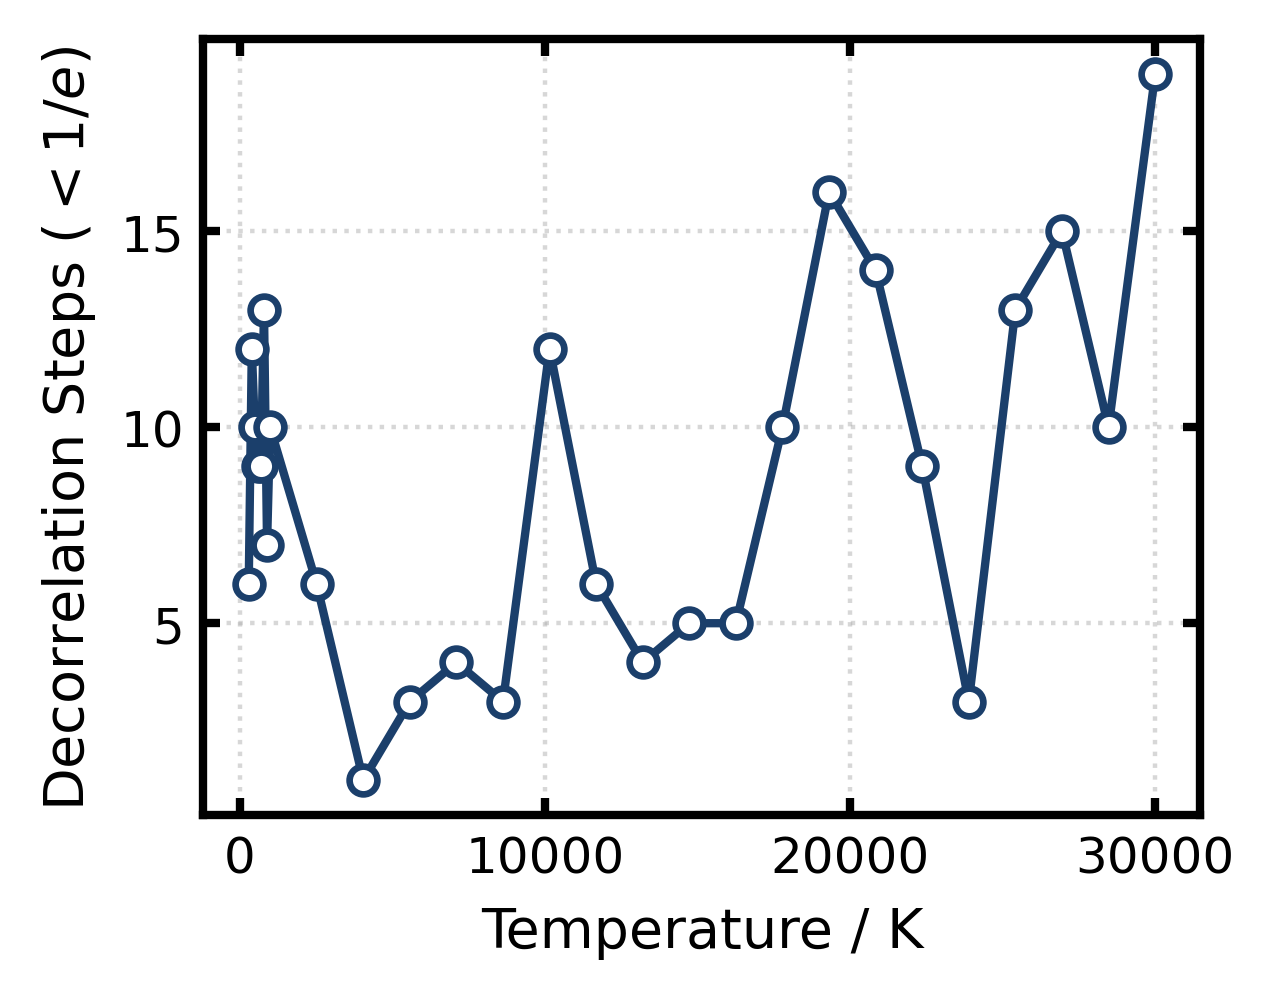

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# The pristine palette
winter_pine = "#22403D"
cranberry   = "#8E2B32"
golden      = "#BEA07B"
oxford_blue = "#1B3F6B"

# ==========================================
# DATA PROCESSING (Untouched)
# ==========================================
autocorr_list_rev = autocorr_list
lag_time_list = [sum(x > 1/np.exp(1.0) for x in autocorr_list_rev[i])-1 for i in range(len(autocorr_list_rev))]
temps = temperatures

# ==========================================
# 1. AESTHETIC SETUP (Journal Standard)
# ==========================================
plt.rcParams.update({
    "font.size": 10,                   
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.5,            
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
})

# Standard single-column width
fig, ax = plt.subplots(figsize=(3.4, 2.6), dpi=400)

# ==========================================
# 2. PLOTTING
# ==========================================
# Using winter_pine for a distinct, elegant look
ax.plot(temps, np.array(lag_time_list), color=oxford_blue, linewidth=1.5, marker='o', 
        markersize=5, markerfacecolor='white', markeredgewidth=1.2, zorder=3)

# ==========================================
# 3. LABELS & FORMATTING
# ==========================================
ax.set_xlabel("Temperature / K")
# Shortened and formalized the y-label for print aesthetics
ax.set_ylabel(r"Decorrelation Steps ($< 1/e$)")

# Grid and Ticks
ax.grid(True, linestyle=':', alpha=0.5, zorder=0)
ax.tick_params(direction='in', top=True, right=True)

# Thicken axes
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.savefig("MC_Decorrelation_Time.png", dpi=400, bbox_inches='tight')
plt.show()

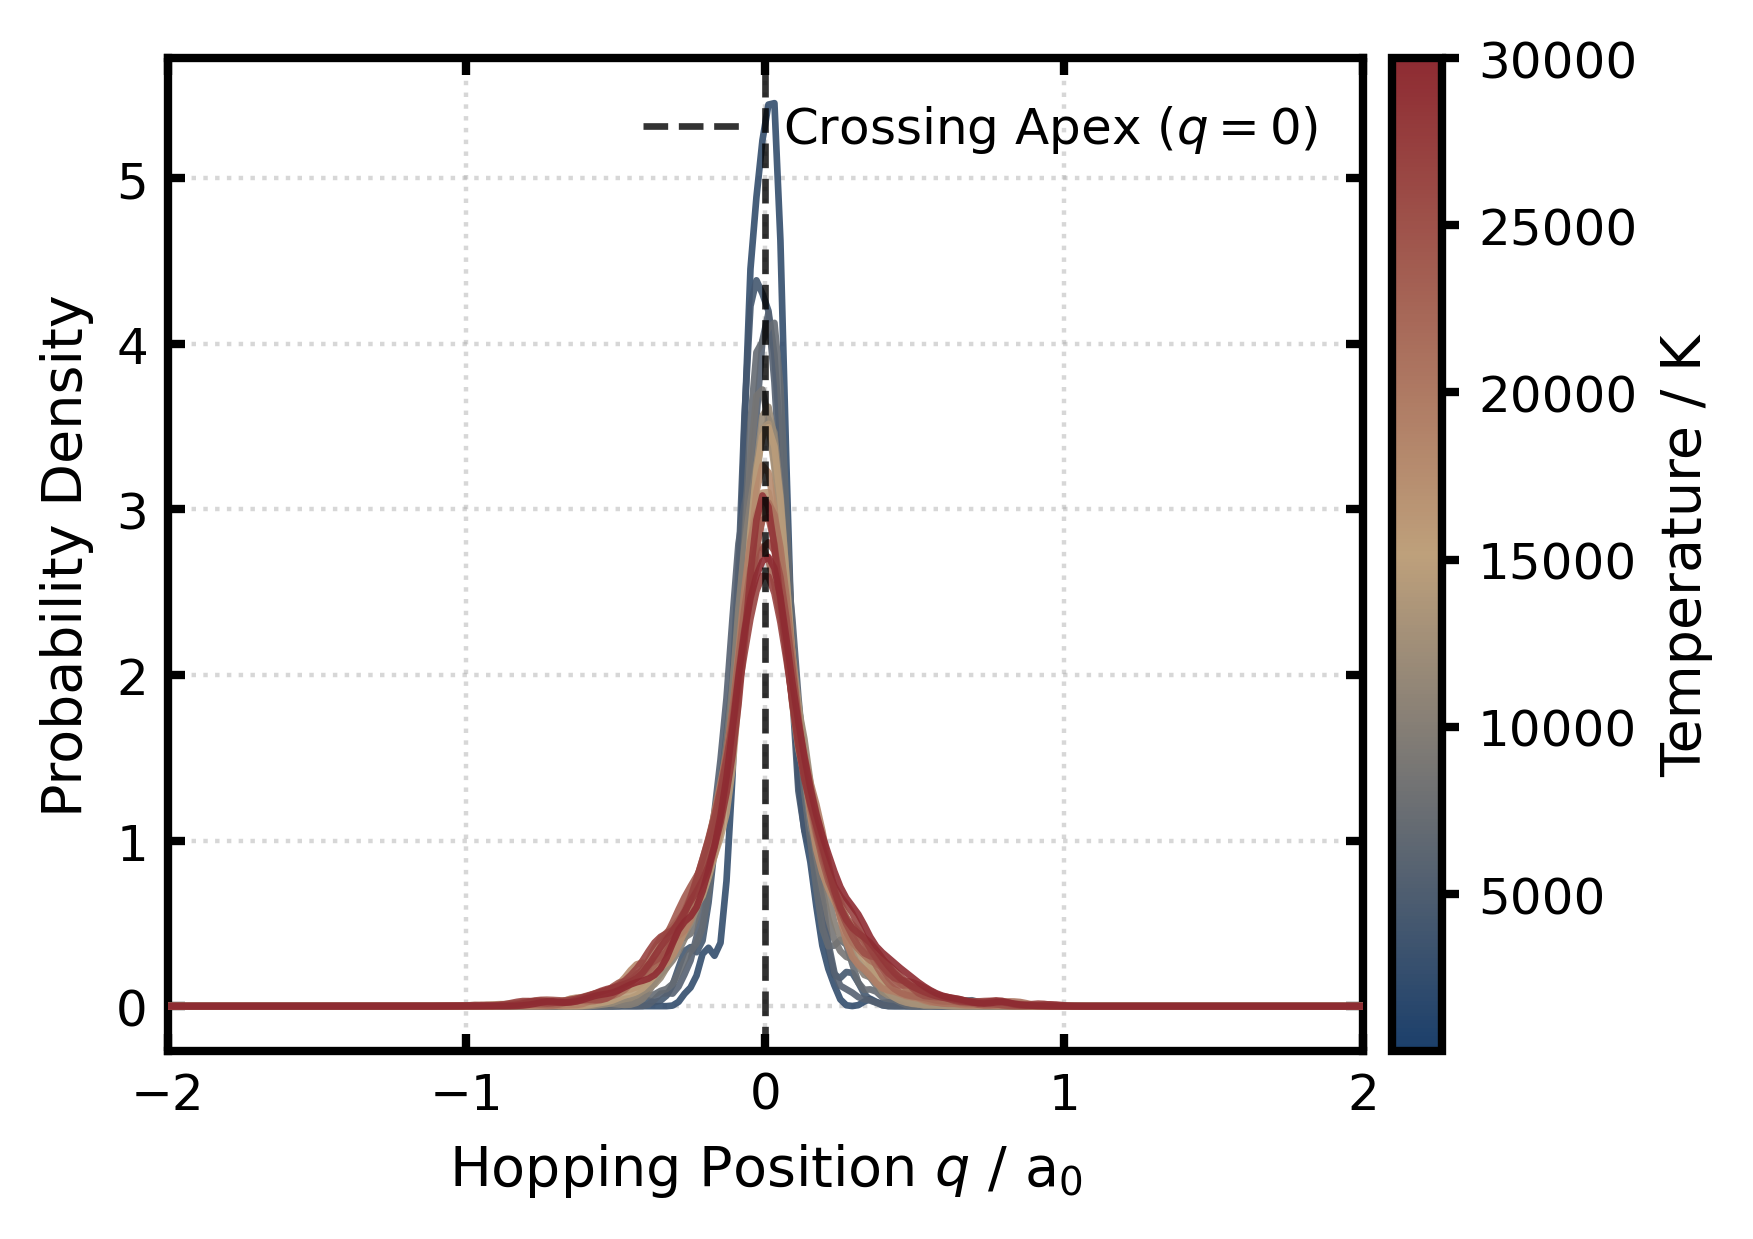

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# The pristine palette
winter_pine = "#22403D"
cranberry   = "#8E2B32"
golden      = "#BEA07B"
oxford_blue = "#1B3F6B"

def plot_hopping_geometry_kde_publish(temperature_sweep, q_hop_dist_list, min_hops=50):
    # ==========================================
    # 1. AESTHETIC SETUP (Journal Standard)
    # ==========================================
    plt.rcParams.update({
        "font.size": 10,                   
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.5,            
        "xtick.major.width": 1.5,
        "ytick.major.width": 1.5,
        "xtick.minor.width": 1.0,
        "ytick.minor.width": 1.0,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
    })

    # A slightly wider format (4.5 x 3.2) accommodates the colorbar perfectly 
    # without shrinking the central plot area too much.
    fig, ax = plt.subplots(figsize=(4.5, 3.2), dpi=400)
    
    # Create the bespoke journal colormap: Blue (Cold) -> Gold (Mid) -> Cranberry (Hot)
    custom_cmap = mcolors.LinearSegmentedColormap.from_list(
        "custom_temp", [oxford_blue, golden, cranberry]
    )
    norm = mcolors.Normalize(vmin=min(temperature_sweep), vmax=max(temperature_sweep))
    
    q_eval = np.linspace(-5, 5, 500) 
    plotted_any = False
    
    # ==========================================
    # 2. PLOTTING THE DISTRIBUTIONS
    # ==========================================
    for temp, q_hops in zip(temperature_sweep, q_hop_dist_list):
        q_hops = np.array(q_hops)
        
        if len(q_hops) < min_hops:
            continue
            
        try:
            kde = gaussian_kde(q_hops, bw_method='scott') 
            density = kde(q_eval)
        except np.linalg.LinAlgError:
            continue
            
        color = custom_cmap(norm(temp))
        
        # Thinner lines for print resolution (1.5 instead of 2.5)
        ax.plot(q_eval, density, color=color, linewidth=1.2, alpha=0.9, zorder=3)
        plotted_any = True
        
    if not plotted_any:
        print("Error: No ensembles met the min_hops criteria.")
        return
        
    # ==========================================
    # 3. LABELS, LEGEND & COLORBAR
    # ==========================================
    # Add a continuous colorbar 
    sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label('Temperature / K', fontweight='medium')
    cbar.outline.set_linewidth(1.5) # Match colorbar border to axes
    
    # Crossing apex indicator
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.2, alpha=0.8, 
               zorder=4, label='Crossing Apex ($q=0$)')
    
    # Journal-standard axis labels
    ax.set_xlabel("Hopping Position $q$ / a$_0$", fontweight='medium')
    ax.set_ylabel("Probability Density", fontweight='medium')
    ax.set_xlim([-2, 2])
    
    # Elegant grid and ticks
    ax.grid(True, linestyle=':', alpha=0.5, zorder=1)
    ax.tick_params(direction='in', top=True, right=True)
    
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    
    # Clean legend without bounding box
    ax.legend(loc='upper right', fontsize=9, frameon=False)
    
    plt.tight_layout()
    plt.savefig("Hopping_Geometry_KDE.png", dpi=400, bbox_inches='tight')
    plt.show()

# Run it:
plot_hopping_geometry_kde_publish(temperatures, q_hop_dist_list)

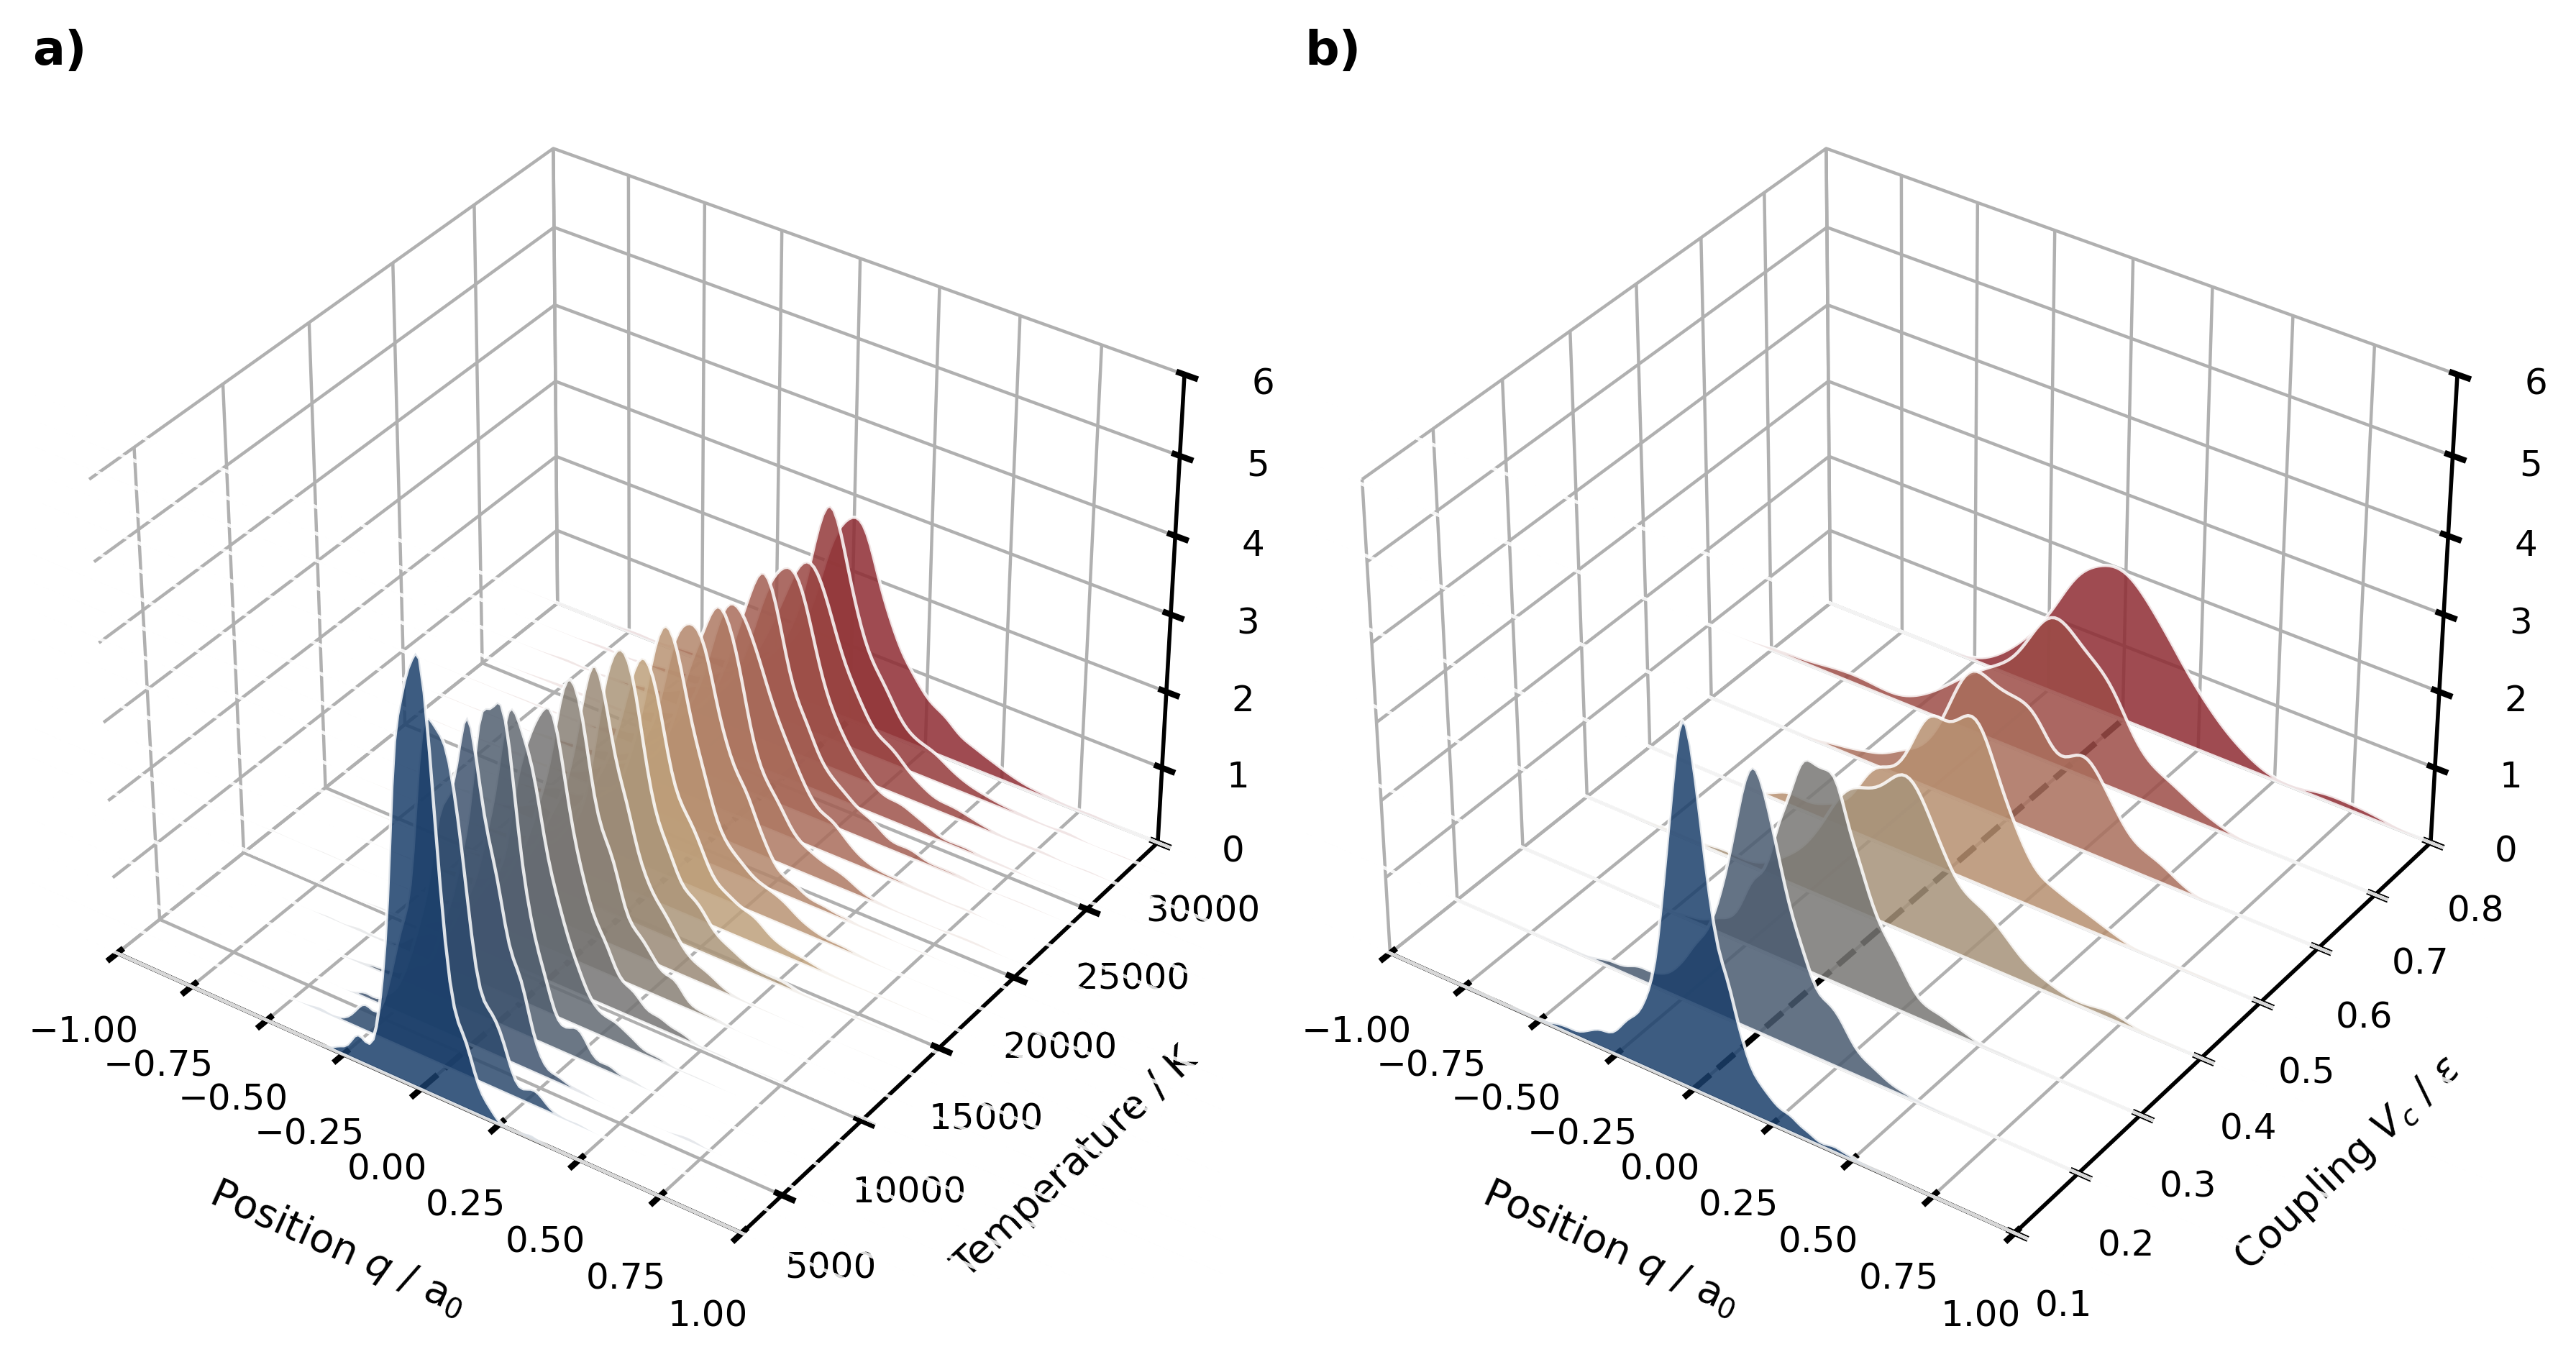

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.colors as mcolors
from matplotlib.collections import PolyCollection

# The pristine palette
winter_pine = "#22403D"
cranberry   = "#8E2B32"
golden      = "#BEA07B"
oxford_blue = "#1B3F6B"

def plot_3d_waterfall_hopping(temperature_sweep, q_dist_T, Vc_sweep, q_dist_Vc, min_hops=50):
    # ==========================================
    # 1. AESTHETIC SETUP
    # ==========================================
    plt.rcParams.update({
        "font.size": 10,                   
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.0,
    })

    # 1x2 Double-column figure for 3D subplots
    fig = plt.figure(figsize=(9.0, 4.5), dpi=400)
    
    # Custom Colormap
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_temp", [oxford_blue, golden, cranberry])
    
    # Define x-axis evaluation points
    q_eval = np.linspace(-3, 3, 500)

    # Helper function to generate polygons for the 3D collection
    def generate_polygons(sweep_vals, dist_list):
        verts = []
        valid_vals = []
        for val, q_hops in zip(sweep_vals, dist_list):
            q_hops = np.array(q_hops)
            if len(q_hops) < min_hops:
                continue
            try:
                kde = gaussian_kde(q_hops, bw_method='scott') 
                density = kde(q_eval)
            except np.linalg.LinAlgError:
                continue
            
            # Close the polygon by pinning the ends to zero so it fills nicely
            density[0], density[-1] = 0, 0 
            verts.append(list(zip(q_eval, density)))
            valid_vals.append(val)
        return verts, valid_vals

    # ==========================================
    # 2. PANEL (a): TEMPERATURE SWEEP
    # ==========================================
    ax1 = fig.add_subplot(121, projection='3d')
    verts_T, valid_T = generate_polygons(temperature_sweep, q_dist_T)
    
    norm_T = mcolors.Normalize(vmin=min(valid_T), vmax=max(valid_T))
    colors_T = [custom_cmap(norm_T(val)) for val in valid_T]
    
    # Create the 3D filled polygons
    poly_T = PolyCollection(verts_T, facecolors=colors_T, edgecolors='white', linewidths=0.8, alpha=0.85)
    ax1.add_collection3d(poly_T, zs=valid_T, zdir='y')
    
    # Aesthetics for Panel (a)
    ax1.set_xlim(-1, 1)
    ax1.set_ylim(min(valid_T), max(valid_T))
    ax1.set_zlim(0, 6.0) # Adjust this upper limit based on your actual peak heights
    
    ax1.set_xlabel('\nPosition $q$ / a$_0$', fontweight='medium')
    ax1.set_ylabel('\nTemperature / K', fontweight='medium')
    ax1.set_zlabel('\nProbability Density', fontweight='medium')
    ax1.set_title('a)', fontweight='bold', loc='left')

    # Draw a vertical line representing the crossing apex at q=0
    ax1.plot([0, 0], [min(valid_T), max(valid_T)], [0, 0], color='black', linestyle='--', linewidth=1.5, zorder=1)

    # ==========================================
    # 3. PANEL (b): V_c GAP SWEEP
    # ==========================================
    ax2 = fig.add_subplot(122, projection='3d')
    verts_Vc, valid_Vc = generate_polygons(Vc_sweep, q_dist_Vc)
    
    norm_Vc = mcolors.Normalize(vmin=min(valid_Vc), vmax=max(valid_Vc))
    colors_Vc = [custom_cmap(norm_Vc(val)) for val in valid_Vc]
    
    poly_Vc = PolyCollection(verts_Vc, facecolors=colors_Vc, edgecolors='white', linewidths=0.8, alpha=0.85)
    ax2.add_collection3d(poly_Vc, zs=valid_Vc, zdir='y')
    
    # Aesthetics for Panel (b)
    ax2.set_xlim(-1, 1)
    ax2.set_ylim(min(valid_Vc), max(valid_Vc))
    ax2.set_zlim(0, 6.0) # Adjust matching Panel (a)
    
    ax2.set_xlabel('\nPosition $q$ / a$_0$', fontweight='medium')
    ax2.set_ylabel('\nCoupling $V_c$ / $\epsilon$', fontweight='medium')
    ax2.set_zlabel('\nProbability Density', fontweight='medium')
    ax2.set_title('b)', fontweight='bold', loc='left')
    
    ax2.plot([0, 0], [min(valid_Vc), max(valid_Vc)], [0, 0], color='black', linestyle='--', linewidth=1.5, zorder=1)

    # ==========================================
    # 4. CAMERA ANGLE & POLISH
    # ==========================================
    # Tweak the viewing angle to get the perfect "NMR Waterfall" perspective
    for ax in [ax1, ax2]:
        ax.view_init(elev=35, azim=-55) 
        
        # Clean up the panes to make it look modern and floaty
        ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax.grid(color='gray', linestyle=':', alpha=0.3)

    plt.tight_layout()
    plt.savefig("3D_Hopping_Geometry_Waterfall.png", dpi=400, bbox_inches='tight')
    plt.show()

# Run it (assuming Vc_v and q_hop_dist_list_V are already defined in your workspace):
plot_3d_waterfall_hopping(temperatures, q_hop_dist_list, Vc_v, q_hop_dist_list_V)

/opt/miniconda3/envs/local_basic/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


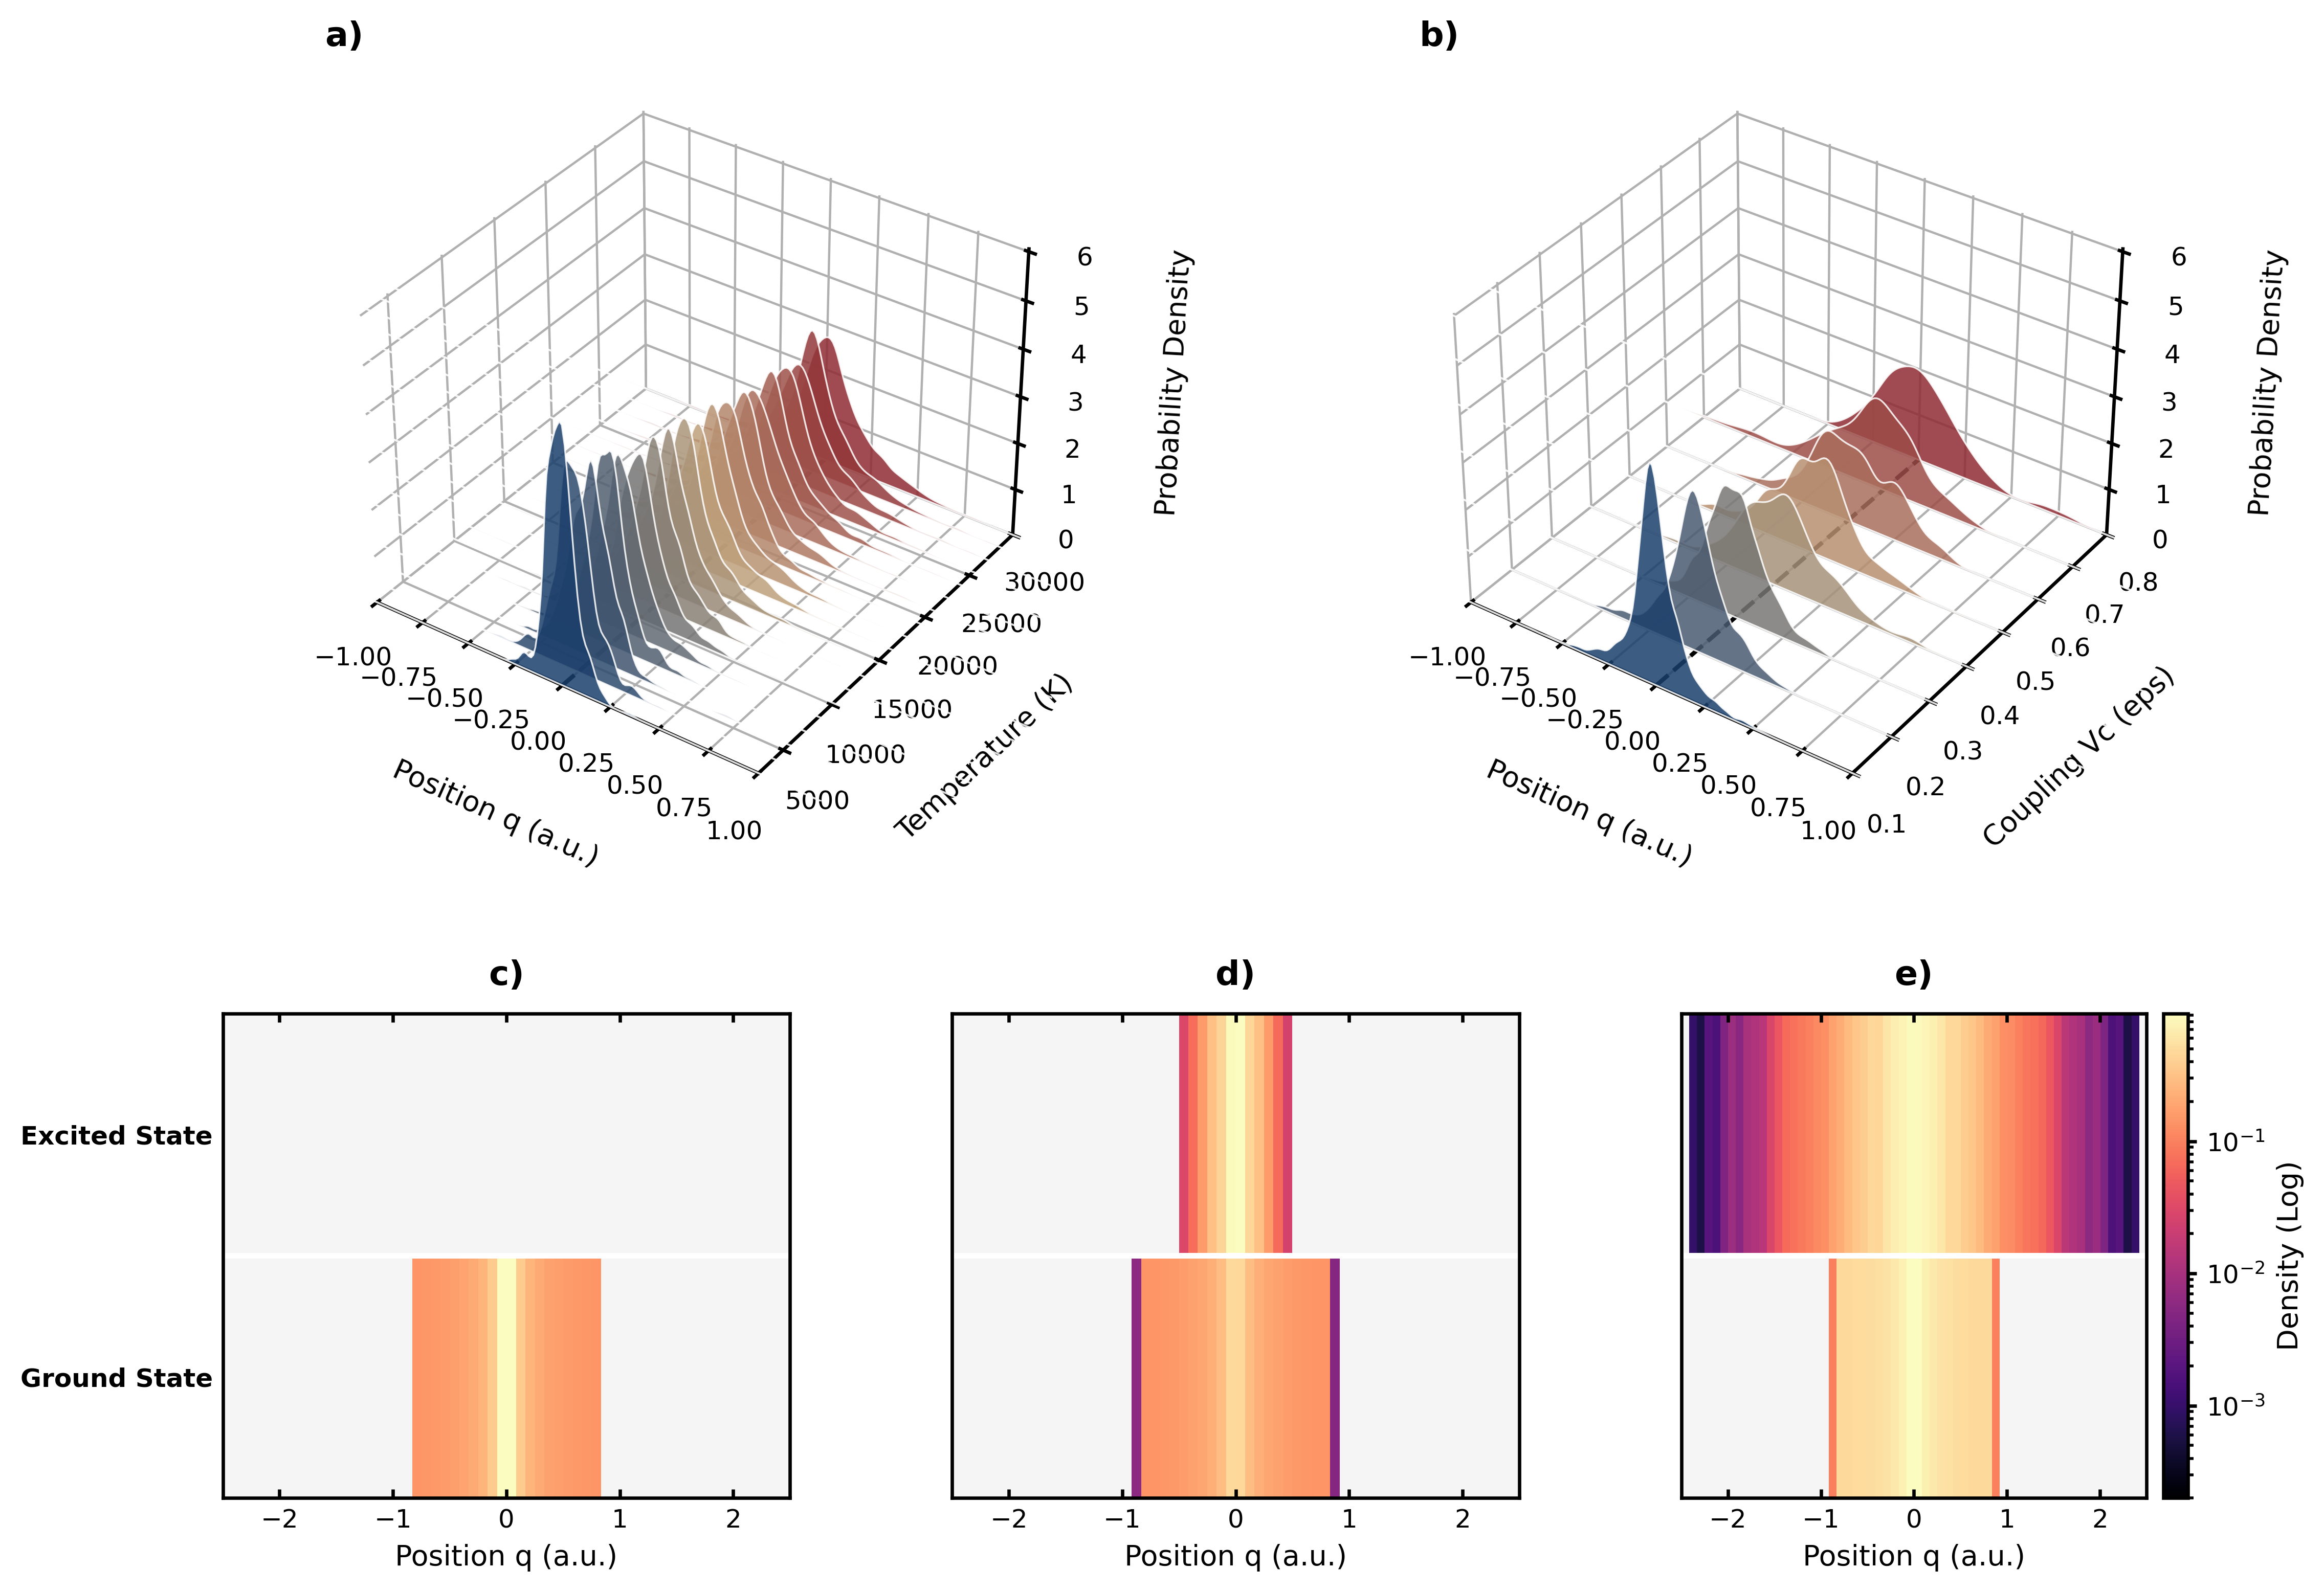

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.colors as mcolors
from matplotlib.collections import PolyCollection
from matplotlib.gridspec import GridSpec
import copy

# The pristine palette
winter_pine = "#22403D"
cranberry   = "#8E2B32"
golden      = "#BEA07B"
oxford_blue = "#1B3F6B"

def plot_mechanistic_superfigure(temperature_sweep, q_dist_T, Vc_sweep, q_dist_Vc, 
                                 state0_pos_list, state1_pos_list, 
                                 target_temps=[2526, 3000, 30000], 
                                 min_hops=50, num_bins=60, density_threshold=2e-4):
    # ==========================================
    # 1. AESTHETIC SETUP
    # ==========================================
    plt.rcParams.update({
        "font.size": 10,                   
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.2,
        "xtick.major.width": 1.2,
        "ytick.major.width": 1.2,
    })

    # A large, beautifully proportioned canvas for a 2-row mixed layout
    fig = plt.figure(figsize=(11.0, 8.0), dpi=400)
    
    # GridSpec: 2 rows, 6 columns. 
    # Row 0: 3D plots get 3 columns each. Row 1: Ribbons get 2 columns each.
    gs = GridSpec(2, 6, height_ratios=[1.5, 1.0], hspace=0.35, wspace=0.8)
    
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_temp", [oxford_blue, golden, cranberry])
    q_eval = np.linspace(-3, 3, 500)

    # Helper for 3D Polygons
    def generate_polygons(sweep_vals, dist_list):
        verts, valid_vals = [], []
        local_max_z = 0
        for val, q_hops in zip(sweep_vals, dist_list):
            q_hops = np.array(q_hops)
            if len(q_hops) < min_hops: continue
            try:
                kde = gaussian_kde(q_hops, bw_method='scott') 
                density = kde(q_eval)
                local_max_z = max(local_max_z, np.max(density)) 
            except np.linalg.LinAlgError:
                continue
            density[0], density[-1] = 0, 0 
            verts.append(list(zip(q_eval, density)))
            valid_vals.append(val)
        return verts, valid_vals, local_max_z

    verts_T, valid_T, max_z_T = generate_polygons(temperature_sweep, q_dist_T)
    verts_Vc, valid_Vc, max_z_Vc = generate_polygons(Vc_sweep, q_dist_Vc)
    global_max_z = max(max_z_T, max_z_Vc) * 1.10 

    # ==========================================
    # 2. TOP ROW: 3D WATERFALL PLOTS
    # ==========================================
    # Panel (a): Temperature Sweep
    ax1 = fig.add_subplot(gs[0, :3], projection='3d')
    norm_T = mcolors.Normalize(vmin=min(valid_T), vmax=max(valid_T))
    poly_T = PolyCollection(verts_T, facecolors=[custom_cmap(norm_T(v)) for v in valid_T], 
                            edgecolors='white', linewidths=0.6, alpha=0.85)
    ax1.add_collection3d(poly_T, zs=valid_T, zdir='y')
    ax1.set(xlim=(-2.5, 2.5), ylim=(min(valid_T), max(valid_T)), zlim=(0, global_max_z))
    ax1.set_xlabel('\nPosition q (a.u.)', fontweight='medium', labelpad=8)
    ax1.set_ylabel('\nTemperature (K)', fontweight='medium', labelpad=8)
    ax1.set_zlabel('\nProbability Density', fontweight='medium', labelpad=8)
    ax1.set_title('a)', fontweight='bold', loc='left', pad=10)
    ax1.set_xlim(-1,1)
    ax1.plot([0, 0], [min(valid_T), max(valid_T)], [0, 0], color='black', linestyle='--', linewidth=1.5, zorder=1)

    # Panel (b): Vc Sweep
    ax2 = fig.add_subplot(gs[0, 3:], projection='3d')
    norm_Vc = mcolors.Normalize(vmin=min(valid_Vc), vmax=max(valid_Vc))
    poly_Vc = PolyCollection(verts_Vc, facecolors=[custom_cmap(norm_Vc(v)) for v in valid_Vc], 
                             edgecolors='white', linewidths=0.6, alpha=0.85)
    ax2.add_collection3d(poly_Vc, zs=valid_Vc, zdir='y')
    ax2.set(xlim=(-2.5, 2.5), ylim=(min(valid_Vc), max(valid_Vc)), zlim=(0, global_max_z))
    ax2.set_xlabel('\nPosition q (a.u.)', fontweight='medium', labelpad=8)
    ax2.set_ylabel('\nCoupling Vc (eps)', fontweight='medium', labelpad=8)
    ax2.set_zlabel('\nProbability Density', fontweight='medium', labelpad=8)
    ax2.set_title('b)', fontweight='bold', loc='left', pad=10)
    ax2.set_xlim(-1,1)
    ax2.plot([0, 0], [min(valid_Vc), max(valid_Vc)], [0, 0], color='black', linestyle='--', linewidth=1.5, zorder=1)

    for ax in [ax1, ax2]:
        ax.view_init(elev=35, azim=-55) 
        ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax.grid(color='gray', linestyle=':', alpha=0.3)

    # ==========================================
    # 3. BOTTOM ROW: 2D PATH DENSITY RIBBONS
    # ==========================================
    ribbon_axes = [fig.add_subplot(gs[1, 0:2]), fig.add_subplot(gs[1, 2:4]), fig.add_subplot(gs[1, 4:6])]
    panel_labels = ['c)', 'd)', 'e)']
    
    ribbon_cmap = copy.copy(plt.cm.magma)
    ribbon_cmap.set_bad(color='whitesmoke') 
    
    grid_bins = np.linspace(-2.5, 2.5, num_bins + 1)
    
    for i, ax in enumerate(ribbon_axes):
        # Find the closest index in the temperature sweep for the requested target
        pos_state0 = state0_pos_list[i]
        pos_state1 = state1_pos_list[i]
        
        density0, _ = np.histogram(pos_state0, bins=grid_bins, density=True)
        density1, _ = np.histogram(pos_state1, bins=grid_bins, density=True)
        heatmap_matrix = np.vstack([density0, density1])
        heatmap_matrix = np.where(heatmap_matrix < density_threshold, np.nan, heatmap_matrix)
        
        max_val = np.nanmax(heatmap_matrix)
        max_val = max_val if not np.isnan(max_val) and max_val > density_threshold else density_threshold * 10
        norm = mcolors.LogNorm(vmin=density_threshold, vmax=max_val)
        
        cax = ax.imshow(heatmap_matrix, aspect='auto', origin='lower', 
                        cmap=ribbon_cmap, norm=norm, interpolation='nearest',
                        extent=[-2.5, 2.5, -0.5, 1.5])
        
        # Labels and Aesthetics
        ax.set_title(f'{panel_labels[i]}', fontweight='bold', pad=10)
        ax.set_xlabel('Position q (a.u.)', fontweight='medium')
        ax.axhline(0.5, color='white', linewidth=2.0, linestyle='-')
        ax.set_xlim(-2.5, 2.5)
        ax.tick_params(axis='x', direction='in', top=True)
        ax.tick_params(axis='y', length=0) 
        
        # Only put the y-axis text on the far left plot to avoid mid-row clutter
        ax.set_yticks([0, 1])
        if i == 0:
            ax.set_yticklabels(['Ground State', 'Excited State'], fontweight='bold')
        else:
            ax.set_yticklabels(['', ''])
            
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)
            
        # Add a sleek colorbar only to the final plot on the right
        if i == 2:
            cbar = fig.colorbar(cax, ax=ax, pad=0.03)
            cbar.set_label('Density (Log)', fontweight='medium')
            cbar.outline.set_linewidth(1.2)

    # Adjust bounding boxes to give the 3D plots height and the ribbons breathing room
    fig.subplots_adjust(top=0.95, bottom=0.08, left=0.05, right=0.95)
    plt.savefig("Mechanistic_Superfigure.png", dpi=400, bbox_inches='tight')
    plt.show()

PD_ensemble_list = [ensemble[1500:] for ensemble in tps_ensemble_list]

state1_pos = [[snap.positions for traj in ensemble for snap in traj if snap.active_state == 1] for ensemble in PD_ensemble_list]
state0_pos = [[snap.positions for traj in ensemble for snap in traj if snap.active_state == 0] for ensemble in PD_ensemble_list]

hot_state_list0 = [state0_pos[0], state0_pos[8], state0_pos[-1]]
hot_state_list1 = [state1_pos[0], state1_pos[8], state1_pos[-1]]

# To run it, make sure you pass in the full lists containing the positions for all temperatures!
plot_mechanistic_superfigure(temperatures, q_hop_dist_list, Vc_v, q_hop_dist_list_V, hot_state_list0, hot_state_list1)

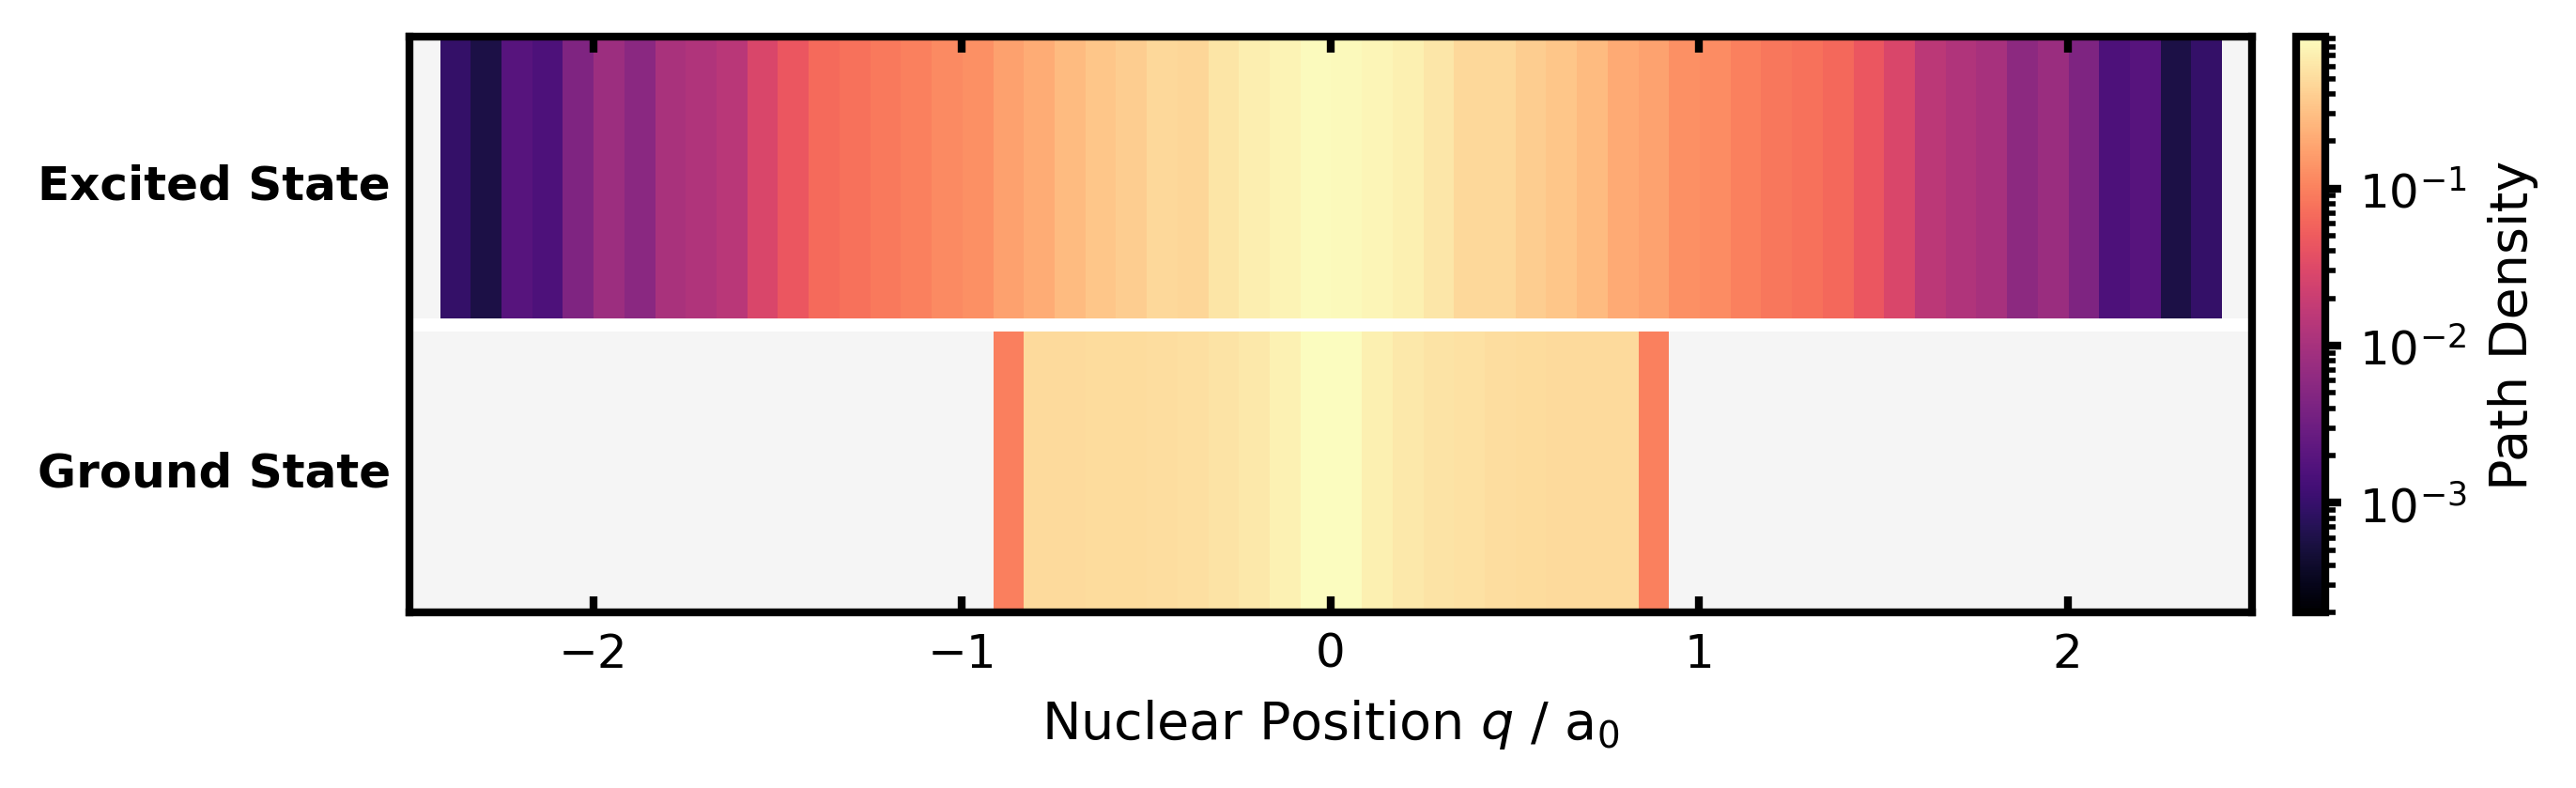

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import copy

PD_ensemble_list = [ensemble[1500:] for ensemble in tps_ensemble_list]

state1_pos = [[snap.positions for traj in ensemble for snap in traj if snap.active_state == 1] for ensemble in PD_ensemble_list]
state0_pos = [[snap.positions for traj in ensemble for snap in traj if snap.active_state == 0] for ensemble in PD_ensemble_list]

# ==========================================
# DATA EXTRACTION (Untouched)
# ==========================================
# Assuming PD_ensemble_list, state1_pos, and state0_pos are already loaded
hot_state0 = state0_pos[-1]
hot_state1 = state1_pos[-1]

def plot_pruned_state_ribbons_publish(pos_state0, pos_state1, num_bins=60, density_threshold=1e-4):
    # ==========================================
    # 1. AESTHETIC SETUP (Journal Standard)
    # ==========================================
    plt.rcParams.update({
        "font.size": 10,                   
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.5,            
        "xtick.major.width": 1.5,
        "ytick.major.width": 1.5,
        "xtick.minor.width": 1.0,
        "ytick.minor.width": 1.0,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
    })

    # 2. Density Math & Pruning (Untouched logic)
    grid_bins = np.linspace(-2.5, 2.5, num_bins + 1)
    density0, _ = np.histogram(pos_state0, bins=grid_bins, density=True)
    density1, _ = np.histogram(pos_state1, bins=grid_bins, density=True)
    heatmap_matrix = np.vstack([density0, density1])
    heatmap_matrix = np.where(heatmap_matrix < density_threshold, np.nan, heatmap_matrix)
    
    # ==========================================
    # 3. PLOTTING THE PRUNED RIBBONS
    # ==========================================
    # A sleek, wide double-column format. The short height (2.2) emphasizes the "ribbon" look.
    fig, ax = plt.subplots(figsize=(7.2, 2.2), dpi=400)
    
    cmap = copy.copy(plt.cm.magma)
    cmap.set_bad(color='whitesmoke') 
    
    max_val = np.nanmax(heatmap_matrix)
    max_val = max_val if not np.isnan(max_val) and max_val > density_threshold else density_threshold * 10
    norm = mcolors.LogNorm(vmin=density_threshold, vmax=max_val)
    
    cax = ax.imshow(heatmap_matrix, aspect='auto', origin='lower', 
                    cmap=cmap, norm=norm, interpolation='nearest',
                    extent=[-2.5, 2.5, -0.5, 1.5])
    
    # ==========================================
    # 4. LABELS, LEGEND & COLORBAR
    # ==========================================
    ax.set_yticks([0, 1])
    # Cleaned up the y-labels to be punchy and journal-appropriate
    ax.set_yticklabels(['Ground State', 'Excited State'], fontweight='bold')
    
    # Unified x-axis coordinate label
    ax.set_xlabel('Nuclear Position $q$ / a$_0$', fontweight='medium')
    
    # Crisp white divider line
    ax.axhline(0.5, color='white', linewidth=2.5, linestyle='-')
    
    # Axis spine and tick styling
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        
    ax.tick_params(axis='x', direction='in', top=True)
    ax.tick_params(axis='y', length=0) # Keeps y-ticks invisible, leaving only the text
    ax.set_xlim(-2.5, 2.5)
    
    # Colorbar styling
    cbar = fig.colorbar(cax, ax=ax, pad=0.02)
    cbar.set_label('Path Density', fontweight='medium')
    cbar.outline.set_linewidth(1.5)
    
    plt.tight_layout()
    plt.savefig("Path_Density_Ribbons.png", dpi=400, bbox_inches='tight')
    plt.show()

# Run it:
plot_pruned_state_ribbons_publish(hot_state0, hot_state1, num_bins=60, density_threshold=2e-4)